In [209]:
!pip install scipy


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [210]:
!pip install scikit-learn --upgrade


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [211]:
!pip install -U nbformat


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [212]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.cluster import KMeans
import plotly.express as px

In [213]:
df =  pd.read_excel(r"C:\Users\salma\OneDrive\Desktop\New folder\Social Media Content Dataset.xlsx")
df.head()

KeyboardInterrupt: 

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5597 entries, 0 to 5596
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Post_ID             5597 non-null   str           
 1   Platform            5597 non-null   str           
 2   Content_Type        5597 non-null   str           
 3   Content_Category    5597 non-null   str           
 4   Post_Type           5597 non-null   str           
 5   Region              5597 non-null   str           
 6   Longitude           5597 non-null   float64       
 7   Latitude            5597 non-null   float64       
 8   Engagement          5597 non-null   int64         
 9   Views               5597 non-null   int64         
 10  Likes               5597 non-null   int64         
 11  Shares              5597 non-null   int64         
 12  Comments            5597 non-null   int64         
 13  Engagement_Rate     5597 non-null   float64       
 14  Imp

In [ ]:
df.groupby('Post_Type')[['Clicks', 'Click_Through_Rate']].apply(
    lambda x: x.notna().sum()
)

,Clicks,Click_Through_Rate
Post_Type,,
Article,206,206
Carousel,25,25
Image,74,74
Live Stream,386,386
PDF,4,4
Text,87,87
Video,1077,1077


In [ ]:
df.groupby('Post_Type')[['Clicks', 'Click_Through_Rate']].apply(
    lambda x: x.isna().sum()
)

,Clicks,Click_Through_Rate
Post_Type,,
Article,0,0
Carousel,26,26
Image,921,921
Live Stream,538,538
PDF,12,12
Text,371,371
Video,1870,1870


In [ ]:
df.groupby('Content_Type')[['Clicks', 'Click_Through_Rate']].apply(
    lambda x: x.notna().sum()
)

,Clicks,Click_Through_Rate
Content_Type,,
Organic,1415,1415
Sponsored,444,444


In [ ]:
df.groupby('Content_Type')[['Clicks', 'Click_Through_Rate']].apply(
    lambda x: x.isna().sum()
)

,Clicks,Click_Through_Rate
Content_Type,,
Organic,3230,3230
Sponsored,508,508


In [ ]:
df.shape

(5597, 24)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

Post_ID                  0
Platform                 0
Content_Type             0
Content_Category         0
Post_Type                0
Region                   0
Longitude                0
Latitude                 0
Engagement               0
Views                    0
Likes                    0
Shares                   0
Comments                 0
Engagement_Rate          0
Impressions              0
Video_Views              0
Live_Stream_Views        0
Clicks                3738
Click_Through_Rate    3738
Main_Hashtag             0
Post_Published_At        0
Post_Date                0
Post_Hour                0
Engagement_Level         0
dtype: int64

In [ ]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].value_counts())


Post_ID
Post_ID
Post_1021    4
Post_2352    4
Post_66      3
Post_85      3
Post_152     3
            ..
Post_2681    1
Post_3024    1
Post_4362    1
Post_81      1
Post_752     1
Name: count, Length: 4998, dtype: int64

Platform
Platform
YouTube      1320
TikTok       1257
X.com        1201
Instagram     998
LinkedIn      522
Facebook      299
Name: count, dtype: int64

Content_Type
Content_Type
Organic      4645
Sponsored     952
Name: count, dtype: int64

Content_Category
Content_Category
Educational          2025
Product Promotion    1385
Entertainment         876
Customer Story        734
Event / Webinar       577
Name: count, dtype: int64

Post_Type
Post_Type
Video          2947
Image           995
Live Stream     924
Text            458
Article         206
Carousel         51
PDF              16
Name: count, dtype: int64

Region
Region
USA          751
Canada       735
UK           732
Brazil       717
India        690
Australia    679
Japan        666
Germany      627
Name: c

C:\Users\salma\AppData\Local\Temp\ipykernel_22148\3184382529.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [ ]:
# Format floats to 2 decimal places (adjust as needed)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Now run your describe code
df[['Engagement', 'Views', 'Likes', 'Shares', 'Comments', 
    'Engagement_Rate', 'Impressions', 'Video_Views', 
    'Clicks', 'Click_Through_Rate']].describe()

,Engagement,Views,Likes,Shares,Comments,Engagement_Rate,Impressions,Video_Views,Clicks,Click_Through_Rate
count,5597.00,5597.00,5597.00,5597.00,5597.00,5597.00,5597.00,5597.00,1859.00,1859.00
mean,115486.01,858610.20,150781.37,47704.09,34531.11,0.15,1030149.78,641284.64,19043.63,0.02
std,129217.20,912016.78,168783.02,53466.86,39806.14,0.05,1096584.56,958928.87,21844.37,0.01
min,73.00,1000.00,101.00,32.00,20.00,0.05,1125.00,0.00,12.00,0.01
25%,37011.00,234372.00,38544.00,12105.00,8593.00,0.10,280580.00,0.00,4787.00,0.01
50%,59027.00,375761.00,67696.00,21125.00,15441.00,0.15,454029.00,100414.00,8229.00,0.02
75%,153494.00,1441124.00,223119.00,71478.00,49252.00,0.20,1719090.00,1122212.00,27811.00,0.02
max,1032271.00,4430104.00,981669.00,304982.00,232658.00,0.27,5282874.00,5474756.00,134139.00,0.03


In [ ]:
df.groupby('Platform')['Engagement_Rate'].mean().sort_values(ascending=False)

Platform
Instagram   0.16
TikTok      0.15
Facebook    0.15
X.com       0.15
YouTube     0.15
LinkedIn    0.14
Name: Engagement_Rate, dtype: float64

In [ ]:
df.groupby('Content_Type')['Engagement_Rate'].mean().sort_values(ascending=False)

Content_Type
Sponsored   0.15
Organic     0.15
Name: Engagement_Rate, dtype: float64

In [ ]:
df.groupby('Content_Category')['Engagement_Rate'].mean().sort_values(ascending=False)

Content_Category
Educational         0.20
Customer Story      0.20
Event / Webinar     0.14
Product Promotion   0.12
Entertainment       0.08
Name: Engagement_Rate, dtype: float64

In [ ]:
df.groupby('Region')['Engagement_Rate'].mean().sort_values(ascending=False)

Region
Australia   0.15
UK          0.15
India       0.15
Brazil      0.15
USA         0.15
Canada      0.15
Japan       0.15
Germany     0.15
Name: Engagement_Rate, dtype: float64

In [ ]:
df['Day'] = df['Post_Date'].dt.day_name()
df['Month'] = df['Post_Date'].dt.month_name()
df['Year'] = df['Post_Date'].dt.year

In [ ]:
df.groupby('Post_Hour')['Engagement_Rate'].mean()

Post_Hour
8    0.15
9    0.15
10   0.15
11   0.15
12   0.15
13   0.16
14   0.16
15   0.15
16   0.16
17   0.16
18   0.16
19   0.15
Name: Engagement_Rate, dtype: float64

In [ ]:
df.groupby('Day')['Engagement_Rate'].mean()

Day
Friday      0.15
Monday      0.15
Saturday    0.15
Sunday      0.15
Thursday    0.15
Tuesday     0.15
Wednesday   0.15
Name: Engagement_Rate, dtype: float64

In [ ]:
df[['Views',
    'Engagement',
    'Likes',
    'Shares',
    'Comments',
    'Impressions',
    'Engagement_Rate']].corr()

,Views,Engagement,Likes,Shares,Comments,Impressions,Engagement_Rate
Views,1.00,0.87,0.95,0.94,0.93,1.00,-0.32
Engagement,0.87,1.00,0.82,0.82,0.81,0.87,0.04
Likes,0.95,0.82,1.00,0.89,0.88,0.94,-0.30
Shares,0.94,0.82,0.89,1.00,0.88,0.94,-0.30
Comments,0.93,0.81,0.88,0.88,1.00,0.93,-0.29
Impressions,1.00,0.87,0.94,0.94,0.93,1.00,-0.32
Engagement_Rate,-0.32,0.04,-0.30,-0.30,-0.29,-0.32,1.00


## Creative Format Efficiency

*Which post format generates the highest total reach vs. active engagement?*

In [ ]:

# 1. Aggregate core metrics by Post_Type
format_analysis = df.groupby('Post_Type').agg(
    Total_Posts=('Post_Type', 'count'),
    Total_Impressions=('Impressions', 'sum'),
    Avg_Impressions=('Impressions', 'mean'),
    Total_Views=('Views', 'sum'),
    Avg_Views=('Views', 'mean'),
    Total_Engagement=('Engagement', 'sum'),
    Total_Likes=('Likes', 'sum'),
    Total_Shares=('Shares', 'sum'),
    Total_Comments=('Comments', 'sum')
).reset_index()

# 2. Compute weighted efficiency metrics
format_analysis['Weighted_Engagement_Rate_%'] = (
    format_analysis['Total_Engagement'] / format_analysis['Total_Impressions']
) * 100

format_analysis['Shares_per_1k'] = (
    format_analysis['Total_Shares'] / format_analysis['Total_Impressions']
) * 1000

format_analysis['Comments_per_1k'] = (
    format_analysis['Total_Comments'] / format_analysis['Total_Impressions']
) * 1000
format_analysis['Likes_per_1k'] = (
    format_analysis['Total_Likes'] / format_analysis['Total_Impressions']
) * 1000

format_analysis['Views_per_Impression_%'] = (
    format_analysis['Total_Views'] /
    format_analysis['Total_Impressions']
) * 100
# 3. Sort by total reach to inspect impresssion efficiency
format_analysis = format_analysis.sort_values(by='Total_Impressions', ascending=False)
print(format_analysis[['Post_Type', 'Views_per_Impression_%','Total_Posts', 'Avg_Impressions', 'Weighted_Engagement_Rate_%', 'Shares_per_1k', 'Comments_per_1k', "Total_Likes", "Likes_per_1k"]])

     Post_Type  Views_per_Impression_%  Total_Posts  Avg_Impressions  \
6        Video                   83.35         2947       1482348.78   
2        Image                   83.39          995        430883.74   
3  Live Stream                   83.15          924        455224.35   
5         Text                   83.49          458        558975.91   
0      Article                   83.58          206       1099218.95   
1     Carousel                   83.00           51        999749.00   
4          PDF                   83.41           16        904535.62   

   Weighted_Engagement_Rate_%  Shares_per_1k  Comments_per_1k  Total_Likes  \
6                       10.81          46.18            33.38    640987396   
2                       13.66          46.39            33.93     62211112   
3                       12.40          46.29            34.22     61053341   
5                       11.95          46.35            34.20     37412120   
0                       11.20    

C:\Users\salma\AppData\Local\Temp\ipykernel_22148\1052221624.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\salma\AppData\Local\Temp\ipykernel_22148\1052221624.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


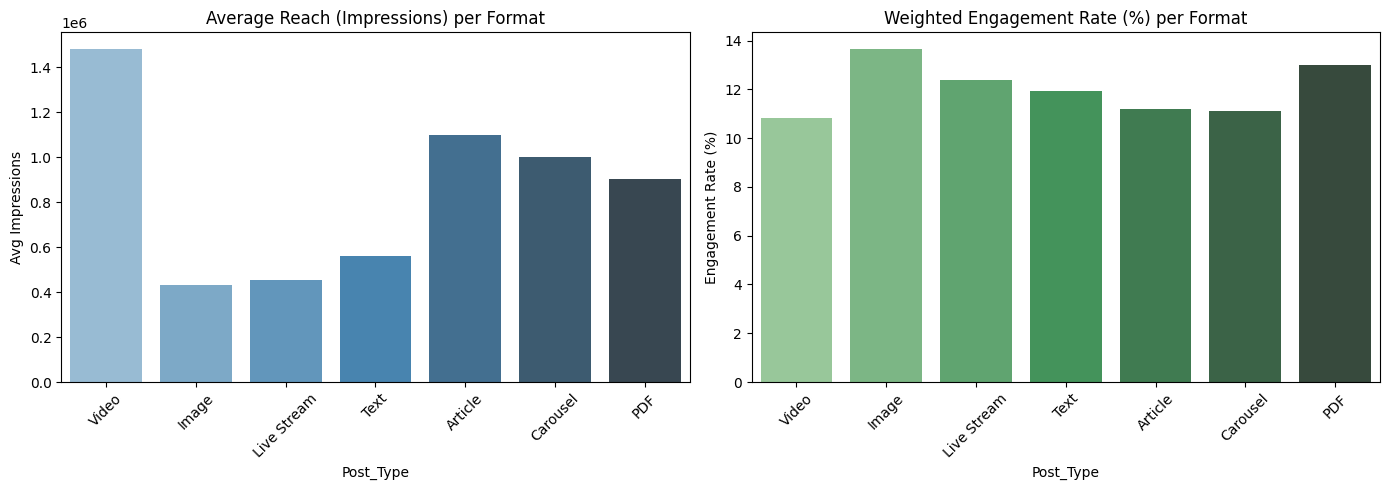

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Average Impressions (Reach) by Post Type
sns.barplot(
    data=format_analysis, 
    x='Post_Type', 
    y='Avg_Impressions', 
    ax=axes[0], 
    palette='Blues_d'
)
axes[0].set_title('Average Reach (Impressions) per Format')
axes[0].set_ylabel('Avg Impressions')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Weighted Engagement Rate (%) by Post Type
sns.barplot(
    data=format_analysis, 
    x='Post_Type', 
    y='Weighted_Engagement_Rate_%', 
    ax=axes[1], 
    palette='Greens_d'
)
axes[1].set_title('Weighted Engagement Rate (%) per Format')
axes[1].set_ylabel('Engagement Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Content Category Effectiveness

In [ ]:
df.Clicks.describe()

count     1859.00
mean     19043.63
std      21844.37
min         12.00
25%       4787.00
50%       8229.00
75%      27811.00
max     134139.00
Name: Clicks, dtype: float64

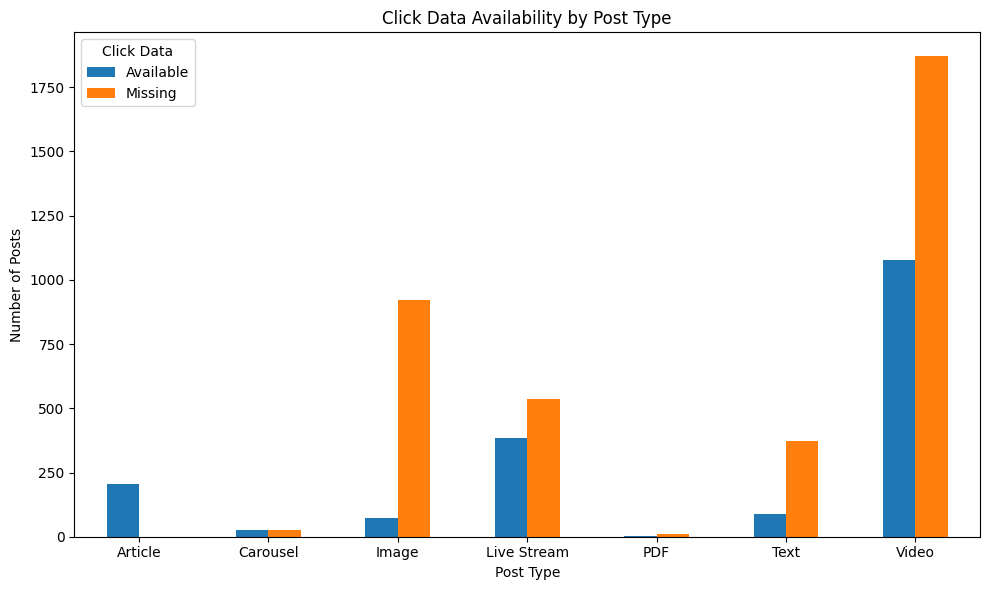

In [ ]:

click_status = (
    df.assign(
        Click_Status=df['Clicks'].notna().map({
            True: 'Available',
            False: 'Missing'
        })
    )
    .groupby(['Post_Type', 'Click_Status'])
    .size()
    .unstack(fill_value=0)
)

click_status.plot(kind='bar', figsize=(10, 6))

plt.title('Click Data Availability by Post Type')
plt.xlabel('Post Type')
plt.ylabel('Number of Posts')
plt.xticks(rotation=0)
plt.legend(title='Click Data')
plt.tight_layout()
plt.show()

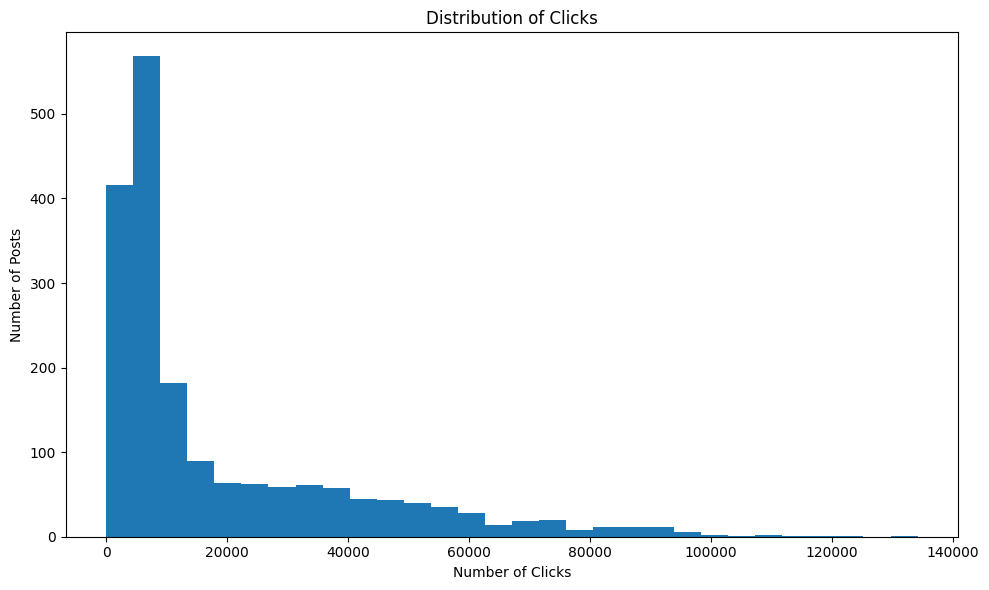

In [ ]:

clicks = df['Clicks'].dropna()

plt.figure(figsize=(10, 6))
plt.hist(clicks, bins=30)

plt.title('Distribution of Clicks')
plt.xlabel('Number of Clicks')
plt.ylabel('Number of Posts')

plt.tight_layout()
plt.show()

In [ ]:

# ==========================================
# 1. DROP MISSING CLICKS IN A NEW COPY
# ==========================================

# Create an independent copy with missing Clicks dropped
df_clicks_clean = df.dropna(subset=['Clicks']).copy()


# ==========================================
# 2. CONTENT CATEGORY EFFECTIVENESS ANALYSIS
# ==========================================

# Aggregate traffic and engagement metrics on the cleaned dataset
category_summary = df_clicks_clean.groupby('Content_Type').agg(
    Clickable_Posts=('Content_Type', 'count'),
    Total_Clicks=('Clicks', 'sum'),
    Total_Impressions=('Impressions', 'sum'),
    Total_Engagement=('Engagement', 'sum'),
    Avg_Clicks_Per_Post=('Clicks', 'mean')
).reset_index()

# Compute true weighted rates across the cleaned records
category_summary['Weighted_CTR_%'] = (
    category_summary['Total_Clicks'] / category_summary['Total_Impressions']
) * 100

category_summary['Weighted_Engagement_Rate_%'] = (
    category_summary['Total_Engagement'] / category_summary['Total_Impressions']
) * 100

# Sort by Total Clicks descending
category_summary = category_summary.sort_values(by='Total_Clicks', ascending=False)

print("--- Content Category Analysis (df_clicks_clean) ---")
print(category_summary[[
    'Content_Type', 
    'Clickable_Posts', 
    'Total_Clicks', 
    'Weighted_CTR_%', 
    'Weighted_Engagement_Rate_%'
]])




--- Content Category Analysis (df_clicks_clean) ---
  Content_Type  Clickable_Posts  Total_Clicks  Weighted_CTR_%  \
0      Organic             1415   25929464.00            1.84   
1    Sponsored              444    9472651.00            1.87   

   Weighted_Engagement_Rate_%  
0                       11.28  
1                       11.09  


In [ ]:
# ==========================================
# 3. ENGAGEMENT TIER DISTRIBUTION
# ==========================================

# Tier breakdown within the cleaned subset
tier_dist_clean = pd.crosstab(
    df_clicks_clean['Content_Type'], 
    df_clicks_clean['Engagement_Level'], 
    normalize='index'
) * 100

# Reorder columns logically
tier_dist_clean = tier_dist_clean[['Low', 'Medium', 'High']].round(2)

print("\n--- Engagement Level Distribution on Cleaned Data (%) ---")
print(tier_dist_clean)




--- Engagement Level Distribution on Cleaned Data (%) ---
Engagement_Level   Low  Medium  High
Content_Type                        
Organic          21.63   55.19 23.18
Sponsored        27.03   46.17 26.80


C:\Users\salma\AppData\Local\Temp\ipykernel_22148\3468929219.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\salma\AppData\Local\Temp\ipykernel_22148\3468929219.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


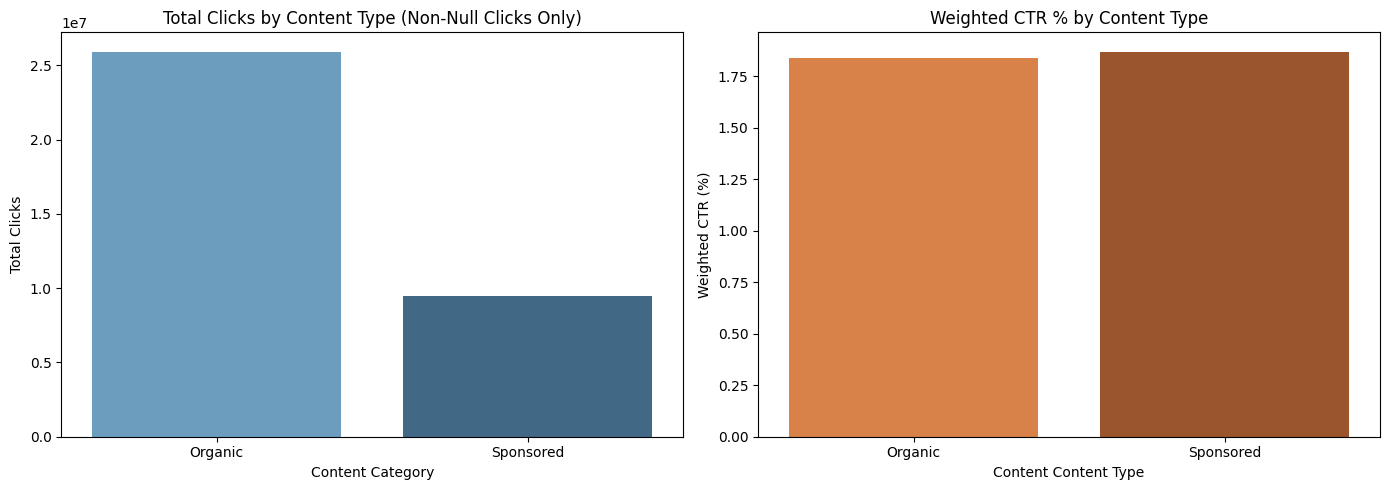

In [ ]:

# ==========================================
# 4. VISUALIZATION
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Total Clicks by Content Category
sns.barplot(
    data=category_summary,
    x='Content_Type',
    y='Total_Clicks',
    ax=axes[0],
    palette='Blues_d'
)
axes[0].set_title('Total Clicks by Content Type (Non-Null Clicks Only)')
axes[0].set_xlabel('Content Category')
axes[0].set_ylabel('Total Clicks')

# Plot 2: Weighted CTR (%) by Content Category
sns.barplot(
    data=category_summary,
    x='Content_Type',
    y='Weighted_CTR_%',
    ax=axes[1],
    palette='Oranges_d'
)
axes[1].set_title('Weighted CTR % by Content Type')
axes[1].set_xlabel('Content Content Type')
axes[1].set_ylabel('Weighted CTR (%)')

plt.tight_layout()
plt.show()

In [ ]:

click_performance = df_clicks_clean.groupby('Content_Type').agg(
    Post_Count=('Clicks', 'count'),
    Total_Clicks=('Clicks', 'sum'),
    Mean_Clicks=('Clicks', 'mean'),
    Median_Clicks=('Clicks', 'median'),
    Total_Impressions=('Impressions', 'sum')
).reset_index()

# 2. Calculate Weighted CTR (%)
click_performance['Weighted_CTR_%'] = (
    click_performance['Total_Clicks'] / click_performance['Total_Impressions']
) * 100

# 3. Sort by Total Clicks
click_performance = click_performance.sort_values(by='Total_Clicks', ascending=False)
print("--- Click Performance Breakdown by Content Type ---")
print(click_performance[['Content_Type', 'Post_Count', 'Total_Clicks', 'Mean_Clicks', 'Median_Clicks', 'Weighted_CTR_%']])

--- Click Performance Breakdown by Content Type ---
  Content_Type  Post_Count  Total_Clicks  Mean_Clicks  Median_Clicks  \
0      Organic        1415   25929464.00     18324.71        7832.00   
1    Sponsored         444    9472651.00     21334.80       10306.00   

   Weighted_CTR_%  
0            1.84  
1            1.87  


C:\Users\salma\AppData\Local\Temp\ipykernel_22148\95318361.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\salma\AppData\Local\Temp\ipykernel_22148\95318361.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


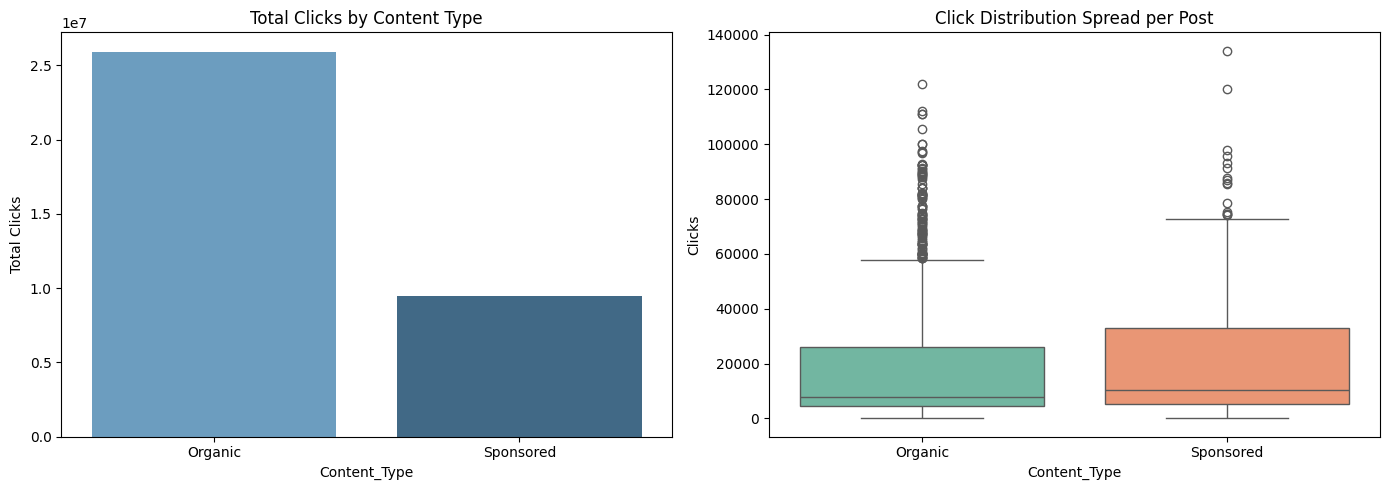

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Total Clicks & Weighted CTR Comparison
sns.barplot(
    data=click_performance, 
    x='Content_Type', 
    y='Total_Clicks', 
    ax=axes[0], 
    palette='Blues_d'
)
axes[0].set_title('Total Clicks by Content Type')
axes[0].set_ylabel('Total Clicks')

# Plot 2: Boxplot of Click Distribution (to spot viral outliers)
sns.boxplot(
    data=df_clicks_clean, 
    x='Content_Type', 
    y='Clicks', 
    ax=axes[1], 
    palette='Set2'
)
axes[1].set_title('Click Distribution Spread per Post')
axes[1].set_ylabel('Clicks')

plt.tight_layout()
plt.show()

In [ ]:

# Ensure required rates exist on the cleaned subset
df_clicks_clean['Calculated_Engagement_Rate_%'] = (
    df_clicks_clean['Engagement'] / df_clicks_clean['Impressions']
) * 100

df_clicks_clean['Calculated_CTR_%'] = (
    df_clicks_clean['Clicks'] / df_clicks_clean['Impressions']
) * 100

# 1. Pearson Correlation (Linear relationship)
pearson_corr, pearson_p = stats.pearsonr(
    df_clicks_clean['Calculated_Engagement_Rate_%'], 
    df_clicks_clean['Calculated_CTR_%']
)

# 2. Spearman Correlation (Monotonic/Rank relationship, robust to outliers)
spearman_corr, spearman_p = stats.spearmanr(
    df_clicks_clean['Calculated_Engagement_Rate_%'], 
    df_clicks_clean['Calculated_CTR_%']
)

print(f"Pearson Correlation Coefficient: {pearson_corr:.3f} (p-value: {pearson_p:.4e})")
print(f"Spearman Rank Correlation: {spearman_corr:.3f} (p-value: {spearman_p:.4e})")

Pearson Correlation Coefficient: -0.022 (p-value: 3.4614e-01)
Spearman Rank Correlation: -0.021 (p-value: 3.6227e-01)


In [ ]:
# Group by Engagement Level and evaluate CTR metrics
tier_ctr_summary = df_clicks_clean.groupby('Engagement_Level').agg(
    Post_Count=('Clicks', 'count'),
    Total_Clicks=('Clicks', 'sum'),
    Total_Impressions=('Impressions', 'sum'),
    Avg_CTR_Per_Post=('Calculated_CTR_%', 'mean')
).reset_index()

# True weighted CTR per tier
tier_ctr_summary['Weighted_CTR_%'] = (
    tier_ctr_summary['Total_Clicks'] / tier_ctr_summary['Total_Impressions']
) * 100

# Order tiers logically
tier_order = {'Low': 1, 'Medium': 2, 'High': 3}
tier_ctr_summary['Sort_Key'] = tier_ctr_summary['Engagement_Level'].map(tier_order)
tier_ctr_summary = tier_ctr_summary.sort_values('Sort_Key').drop(columns=['Sort_Key'])

print("\n--- Weighted CTR across Engagement Levels ---")
print(tier_ctr_summary[['Engagement_Level', 'Post_Count', 'Total_Clicks', 'Avg_CTR_Per_Post', 'Weighted_CTR_%']])


--- Weighted CTR across Engagement Levels ---
  Engagement_Level  Post_Count  Total_Clicks  Avg_CTR_Per_Post  Weighted_CTR_%
1              Low         426   12174971.00              1.86            1.89
2           Medium         986   17762497.00              1.83            1.83
0             High         447    5464647.00              1.81            1.81


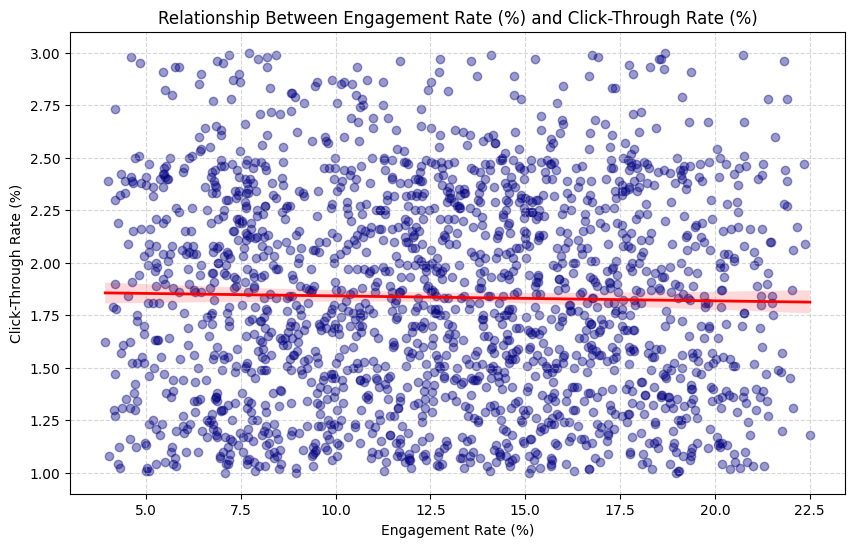

In [ ]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_clicks_clean,
    x='Calculated_Engagement_Rate_%',
    y='Calculated_CTR_%',
    scatter_kws={'alpha': 0.4, 'color': 'navy'},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title('Relationship Between Engagement Rate (%) and Click-Through Rate (%)')
plt.xlabel('Engagement Rate (%)')
plt.ylabel('Click-Through Rate (%)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

---

## 📌 Key Insight: The Engagement-Conversion Divide

### Statistical Findings
To test whether high in-feed engagement translates to higher website traffic, we performed correlation analysis between **Engagement Rate (%)** and **Click-Through Rate (CTR %)** on the cleaned traffic dataset (`df_clicks_clean`):

* **Pearson Correlation ($r$):** `-0.022` ($p$-value = `0.346`)
* **Spearman Rank Correlation ($\rho$):** `-0.021` ($p$-value = `0.362`)

---

### 💡 Core Takeaways

1. **Decoupled User Behaviors**  
   With $r \approx 0.00$ and $p > 0.05$, there is **no statistically significant relationship** between Engagement Rate and CTR. A post that receives high Likes, Comments, or Shares is **no more likely** to generate link clicks than a low-engagement post.

2. **In-Feed Interactions vs. Outbound Intent**  
   * **In-Feed Engagement (Likes/Shares/Comments):** Driven by passive consumption, entertaining visuals, and quick emotional or conversational reactions within the platform feed.
   * **Outbound Traffic (Clicks/CTR):** Driven by explicit utility, strong calls-to-action (CTAs), curiosity, or promotional offers requiring users to leave the app.

---

### 🎯 Strategic Business Recommendations

* **Separate Campaign Track Goals:** Avoid using high-engagement content (e.g., viral memes or general entertainment) as a proxy measure for website traffic generation.
* **Dual-Track Content Strategy:**
  * **Awareness Track:** Optimize for reach, shares, and comments using broad-appeal creative assets.
  * **Conversion Track:** Focus on high-intent creative, clear CTA placement, and dedicated landing page messaging to optimize CTR—independent of anticipated in-feed engagement levels.

---

In [ ]:

# ==========================================
# 1. OVERALL ENGAGEMENT BY COMBINATION (Full Dataset)
# ==========================================

combo_engagement = df.groupby(['Content_Type', 'Post_Type']).agg(
    Total_Posts=('Post_Type', 'count'),
    Total_Impressions=('Impressions', 'sum'),
    Total_Engagement=('Engagement', 'sum'),
    Avg_Impressions=('Impressions', 'mean')
).reset_index()

combo_engagement['Weighted_Engagement_Rate_%'] = (
    combo_engagement['Total_Engagement'] / combo_engagement['Total_Impressions']
) * 100


# ==========================================
# 2. TRAFFIC & CTR BY COMBINATION (Cleaned Clicks Subset)
# ==========================================

combo_clicks = df_clicks_clean.groupby(['Content_Type', 'Post_Type']).agg(
    Clickable_Posts=('Clicks', 'count'),
    Total_Clicks=('Clicks', 'sum'),
    Click_Impressions=('Impressions', 'sum')
).reset_index()

combo_clicks['Weighted_CTR_%'] = (
    combo_clicks['Total_Clicks'] / combo_clicks['Click_Impressions']
) * 100


# ==========================================
# 3. MERGE METRICS INTO A MATRIX SUMMARY
# ==========================================

combo_summary = pd.merge(
    combo_engagement, 
    combo_clicks[['Content_Type', 'Post_Type', 'Total_Clicks', 'Weighted_CTR_%']], 
    on=['Content_Type', 'Post_Type'], 
    how='left'
)

# Fill missing click combinations with 0
combo_summary['Total_Clicks'] = combo_summary['Total_Clicks'].fillna(0)

# Sort by Top Performing Combinations
print("--- Top 10 Combinations by Total Clicks ---")
print(combo_summary.sort_values(by='Total_Clicks', ascending=False)[
    ['Content_Type', 'Post_Type', 'Total_Posts', 'Avg_Impressions', 'Weighted_Engagement_Rate_%', 'Total_Clicks', 'Weighted_CTR_%']
].head(10))

--- Top 10 Combinations by Total Clicks ---
   Content_Type    Post_Type  Total_Posts  Avg_Impressions  \
6       Organic        Video         2280       1519494.05   
13    Sponsored        Video          667       1355375.43   
0       Organic      Article          150       1123895.98   
3       Organic  Live Stream          910        457225.53   
9     Sponsored        Image          162        567980.82   
7     Sponsored      Article           56       1033119.77   
5       Organic         Text          416        500196.32   
2       Organic        Image          833        404221.40   
12    Sponsored         Text           42       1141173.79   
1       Organic     Carousel           41       1025950.32   

    Weighted_Engagement_Rate_%  Total_Clicks  Weighted_CTR_%  
6                        10.82   17048398.00            1.80  
13                       10.75    5911957.00            1.74  
0                        11.38    3384264.00            2.01  
3                    

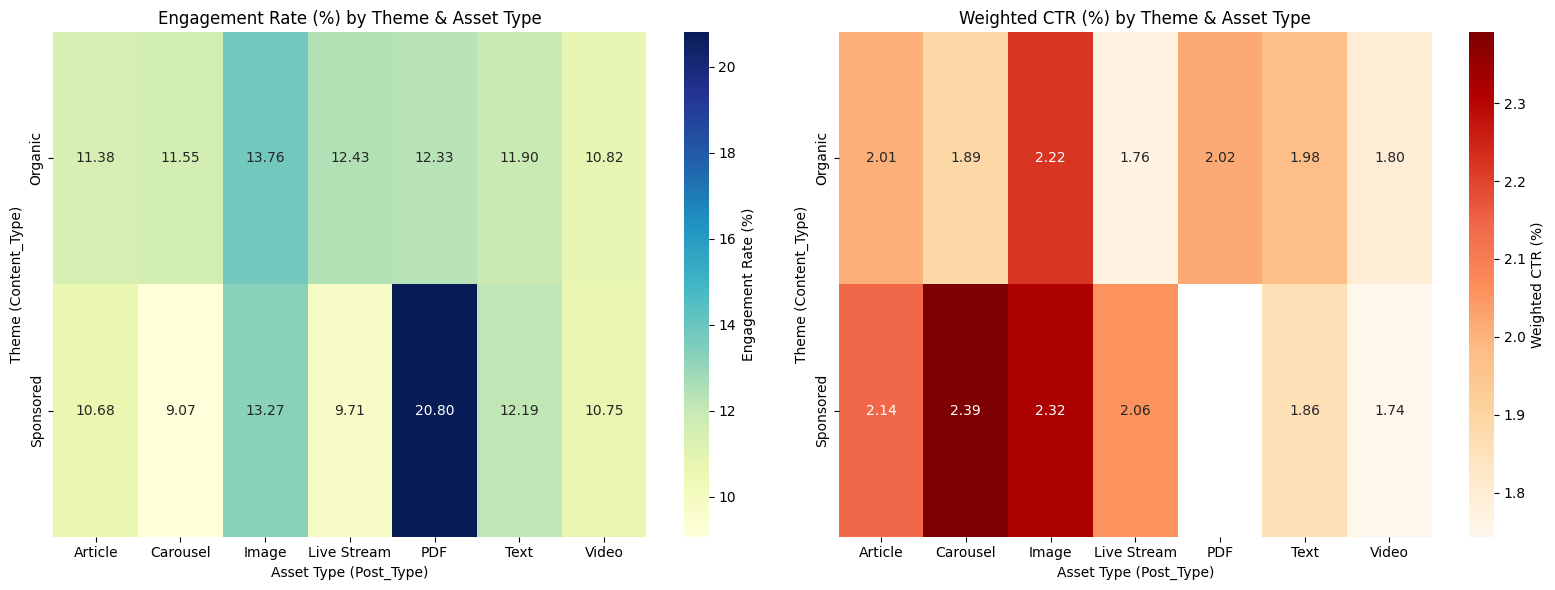

In [ ]:
# Pivot data for heatmap grids
pivot_engagement = combo_summary.pivot(index='Content_Type', columns='Post_Type', values='Weighted_Engagement_Rate_%')
pivot_ctr = combo_summary.pivot(index='Content_Type', columns='Post_Type', values='Weighted_CTR_%')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap 1: Weighted Engagement Rate (%)
sns.heatmap(
    pivot_engagement, 
    annot=True, 
    fmt=".2f", 
    cmap="YlGnBu", 
    ax=axes[0], 
    cbar_kws={'label': 'Engagement Rate (%)'}
)
axes[0].set_title('Engagement Rate (%) by Theme & Asset Type')
axes[0].set_xlabel('Asset Type (Post_Type)')
axes[0].set_ylabel('Theme (Content_Type)')

# Heatmap 2: Weighted CTR (%)
sns.heatmap(
    pivot_ctr, 
    annot=True, 
    fmt=".2f", 
    cmap="OrRd", 
    ax=axes[1], 
    cbar_kws={'label': 'Weighted CTR (%)'}
)
axes[1].set_title('Weighted CTR (%) by Theme & Asset Type')
axes[1].set_xlabel('Asset Type (Post_Type)')
axes[1].set_ylabel('Theme (Content_Type)')

plt.tight_layout()
plt.show()

## Audience & Geographic Insights

In [ ]:
(df['Engagement'] == (
    df['Likes'] +
    df['Comments'] +
    df['Shares']
)).value_counts()

False    5597
Name: count, dtype: int64

In [ ]:
# Create a temporary calculated column
calculated_engagement = df['Likes'] + df['Comments'] + df['Shares']

# Filter rows where Engagement does not equal the sum
discrepancy_df = df[df['Engagement'] != calculated_engagement].copy()

# Calculate the exact difference
discrepancy_df['Difference'] = discrepancy_df['Engagement'] - calculated_engagement

# Display the main interaction columns alongside the difference
print(discrepancy_df['Difference'].head(100))

0    -122878
1    -169247
2     -36076
3    -137587
4        283
       ...  
95   -148110
96    -47825
97   -188355
98    -48952
99   -592218
Name: Difference, Length: 100, dtype: int64


In [ ]:
# Check 1: Does Engagement include Clicks? (Filling NaN Clicks with 0)
clicks_included = (
    df['Engagement'] == (df['Likes'] + df['Comments'] + df['Shares'] + df['Clicks'].fillna(0))
).value_counts()

print("Includes Clicks?:")
print(clicks_included)

# Check 2: Check for near-equality (handles floating-point rounding)
import numpy as np
is_close = np.isclose(
    df['Engagement'], 
    (df['Likes'] + df['Comments'] + df['Shares']), 
    atol=1e-2
)
print("\nIs it just rounding differences?:")
print(pd.Series(is_close).value_counts())


Includes Clicks?:
False    5597
Name: count, dtype: int64

Is it just rounding differences?:
False    5597
Name: count, dtype: int64


In [ ]:

# ==========================================
# 1. CREATE NEW METRICS & AGGREGATE REGIONALLY
# ==========================================

# Define pure social interactions
df['Social_Interactions'] = df['Likes'] + df['Comments'] + df['Shares']

# Aggregate by Region
geo_eval = df.groupby('Region').agg(
    Total_Posts=('Region', 'count'),
    Total_Impressions=('Impressions', 'sum'),
    Avg_Impressions=('Impressions', 'mean'),
    
    # Pure Social Interaction Metrics
    Total_Social_Interactions=('Social_Interactions', 'sum'),
    Total_Likes=('Likes', 'sum'),
    Total_Comments=('Comments', 'sum'),
    Total_Shares=('Shares', 'sum'),
    
    # Dataset Engagement Metric
    Total_Dataset_Engagement=('Engagement', 'sum')
).reset_index()

# Calculate true weighted rates relative to Impressions
geo_eval['Social_Interaction_Rate_%'] = (
    geo_eval['Total_Social_Interactions'] / geo_eval['Total_Impressions']
) * 100

geo_eval['Dataset_Engagement_Rate_%'] = (
    geo_eval['Total_Dataset_Engagement'] / geo_eval['Total_Impressions']
) * 100

# Per 1,000 Impressions Breakdown
geo_eval['Likes_per_1k'] = (geo_eval['Total_Likes'] / geo_eval['Total_Impressions']) * 1000
geo_eval['Comments_per_1k'] = (geo_eval['Total_Comments'] / geo_eval['Total_Impressions']) * 1000
geo_eval['Shares_per_1k'] = (geo_eval['Total_Shares'] / geo_eval['Total_Impressions']) * 1000

# Sort by Total Impressions
geo_eval = geo_eval.sort_values(by='Total_Impressions', ascending=False)

print("--- Demographic Performance Evaluation ---")
print(geo_eval[[
    'Region', 'Total_Posts', 'Total_Impressions', 
    'Total_Social_Interactions', 'Social_Interaction_Rate_%', 
    'Total_Dataset_Engagement', 'Dataset_Engagement_Rate_%'
]])

--- Demographic Performance Evaluation ---
      Region  Total_Posts  Total_Impressions  Total_Social_Interactions  \
7        USA          751          807448592                  182860777   
5      Japan          666          745674763                  173760570   
6         UK          732          733408049                  166228633   
0  Australia          679          722396800                  164643243   
1     Brazil          717          719963138                  160850405   
2     Canada          735          718829640                  159715383   
4      India          690          676934069                  151697431   
3    Germany          627          641093252                  144437281   

   Social_Interaction_Rate_%  Total_Dataset_Engagement  \
7                      22.65                  90506352   
5                      23.30                  82781768   
6                      22.67                  82036136   
0                      22.79                  793

C:\Users\salma\AppData\Local\Temp\ipykernel_22148\4243949991.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\salma\AppData\Local\Temp\ipykernel_22148\4243949991.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


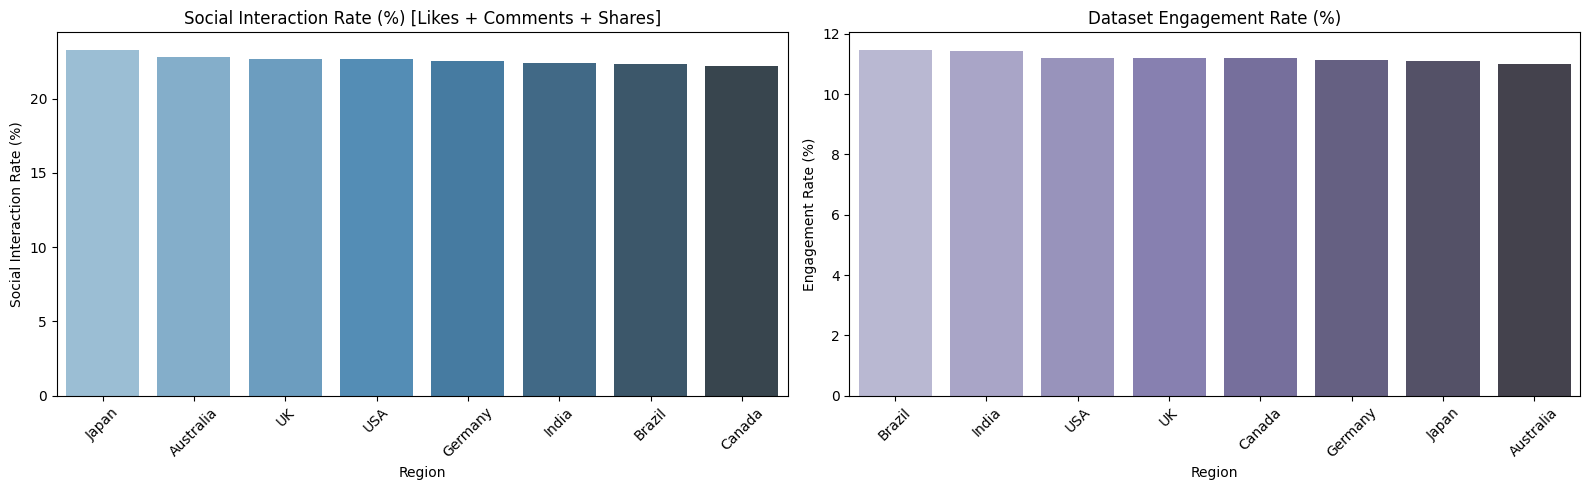

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Explicit Social Interaction Rate (Likes + Comments + Shares)
sns.barplot(
    data=geo_eval.sort_values(by='Social_Interaction_Rate_%', ascending=False),
    x='Region',
    y='Social_Interaction_Rate_%',
    ax=axes[0],
    palette='Blues_d'
)
axes[0].set_title('Social Interaction Rate (%) [Likes + Comments + Shares]')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Social Interaction Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Dataset Engagement Rate (%)
sns.barplot(
    data=geo_eval.sort_values(by='Dataset_Engagement_Rate_%', ascending=False),
    x='Region',
    y='Dataset_Engagement_Rate_%',
    ax=axes[1],
    palette='Purples_d'
)
axes[1].set_title('Dataset Engagement Rate (%)')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Engagement Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:

# Ensure Social_Interactions column exists
df['Social_Interactions'] = df['Likes'] + df['Comments'] + df['Shares']


# ==========================================
# 1. SPATIAL CLUSTERING (K-MEANS)
# ==========================================

# Extract spatial coordinates (adjust column names if yours differ, e.g., 'lat', 'long')
coords = df[['Latitude', 'Longitude']].dropna()

# Fit K-Means to cluster geographic locations into spatial hubs (e.g., 5 clusters)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df.loc[coords.index, 'Spatial_Cluster'] = kmeans.fit_predict(coords)
df['Spatial_Cluster'] = df['Spatial_Cluster'].astype(int)


# ==========================================
# 2. SPATIAL CLUSTER METRICS SUMMARY
# ==========================================

cluster_summary = df.groupby('Spatial_Cluster').agg(
    Post_Count=('Spatial_Cluster', 'count'),
    Center_Lat=('Latitude', 'mean'),
    Center_Long=('Longitude', 'mean'),
    Total_Impressions=('Impressions', 'sum'),
    Total_Social_Interactions=('Social_Interactions', 'sum'),
    Total_Dataset_Engagement=('Engagement', 'sum')
).reset_index()

cluster_summary['Social_Interaction_Rate_%'] = (
    cluster_summary['Total_Social_Interactions'] / cluster_summary['Total_Impressions']
) * 100

print("--- Spatial Clusters Geographic Summary ---")
print(cluster_summary[['Spatial_Cluster', 'Post_Count', 'Center_Lat', 'Center_Long', 'Total_Impressions', 'Social_Interaction_Rate_%']])


# ==========================================
# 3. REGIONAL CONTENT & HASHTAG PREFERENCES
# ==========================================

# A. Content Type Preference per Spatial Cluster (%)
cluster_content = pd.crosstab(
    df['Spatial_Cluster'], 
    df['Content_Type'], 
    normalize='index'
) * 100

print("\n--- Content Type Preferences by Spatial Cluster (%) ---")
print(cluster_content.round(2))

# B. Primary Hashtag Preference per Spatial Cluster (%)
if 'Primary_Hashtag' in df.columns or 'Hashtag' in df.columns:
    hashtag_col = 'Primary_Hashtag' if 'Primary_Hashtag' in df.columns else 'Hashtag'
    cluster_hashtags = pd.crosstab(
        df['Spatial_Cluster'], 
        df[hashtag_col], 
        normalize='index'
    ) * 100
    
    print(f"\n--- Hashtag Preferences by Spatial Cluster (%) [{hashtag_col}] ---")
    print(cluster_hashtags.round(2))

--- Spatial Clusters Geographic Summary ---
   Spatial_Cluster  Post_Count  Center_Lat  Center_Long  Total_Impressions  \
0                0         679      -25.27       133.78          722396800   
1                1        1486       46.51      -100.97         1526278232   
2                2        1359       53.43         2.97         1374501301   
3                3        1356       28.26       108.08         1422608832   
4                4         717      -14.23       -51.93          719963138   

   Social_Interaction_Rate_%  
0                      22.79  
1                      22.45  
2                      22.60  
3                      22.88  
4                      22.34  

--- Content Type Preferences by Spatial Cluster (%) ---
Content_Type     Organic  Sponsored
Spatial_Cluster                    
0                  82.77      17.23
1                  82.71      17.29
2                  83.00      17.00
3                  83.11      16.89
4                  83.54    

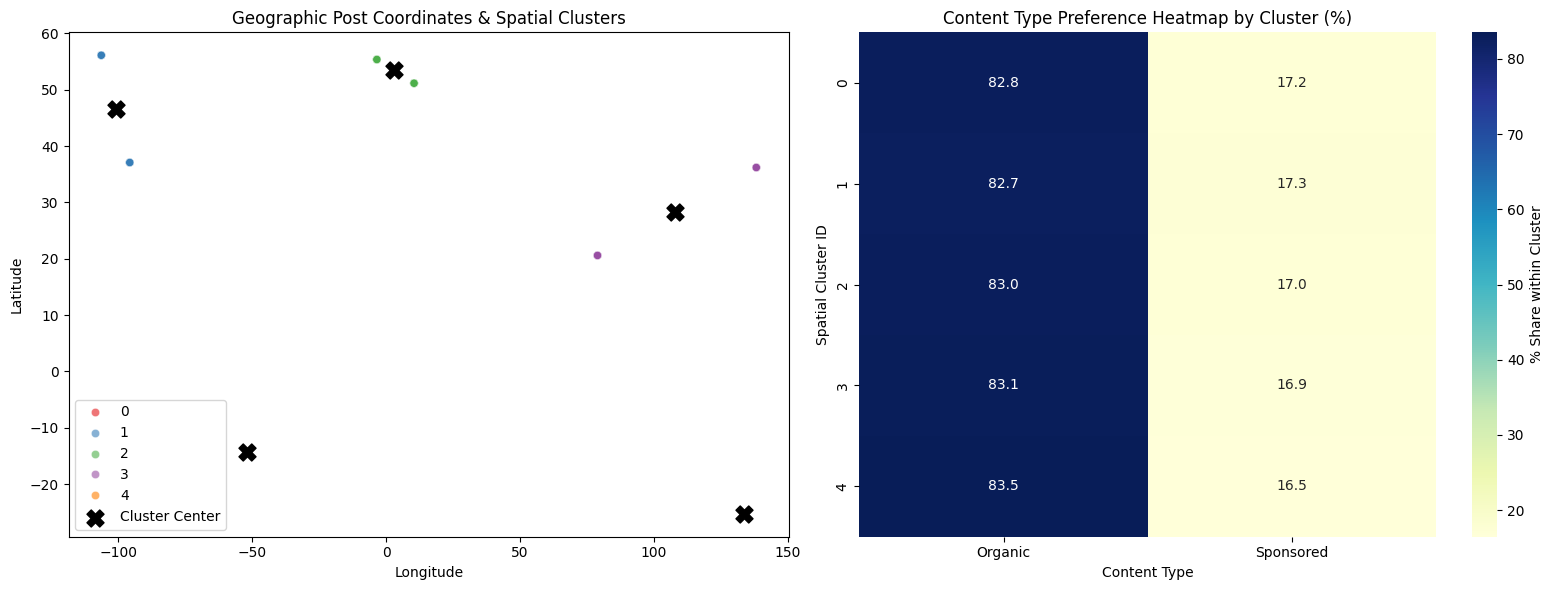

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Geospatial Coordinate Scatter Map
sns.scatterplot(
    data=df,
    x='Longitude',
    y='Latitude',
    hue='Spatial_Cluster',
    palette='Set1',
    alpha=0.6,
    ax=axes[0]
)
# Plot Cluster Centers
axes[0].scatter(
    cluster_summary['Center_Long'], 
    cluster_summary['Center_Lat'], 
    c='black', 
    marker='X', 
    s=150, 
    label='Cluster Center'
)
axes[0].set_title('Geographic Post Coordinates & Spatial Clusters')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].legend()

# Plot 2: Content Type Share per Spatial Cluster
sns.heatmap(
    cluster_content,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    ax=axes[1],
    cbar_kws={'label': '% Share within Cluster'}
)
axes[1].set_title('Content Type Preference Heatmap by Cluster (%)')
axes[1].set_xlabel('Content Type')
axes[1].set_ylabel('Spatial Cluster ID')

plt.tight_layout()
plt.show()

In [ ]:


geo_map = df.groupby('Region').agg(
    Latitude=('Latitude', 'mean'),
    Longitude=('Longitude', 'mean'),
    Total_Impressions=('Impressions', 'sum'),
    Total_Engagement=('Engagement', 'sum'),
    Total_Posts=('Post_ID', 'count')
).reset_index()

geo_map['Engagement_Rate'] = (
    geo_map['Total_Engagement'] /
    geo_map['Total_Impressions']
) * 100

In [ ]:
fig = px.choropleth(
    geo_map,
    locations='Region',
    locationmode='country names',
    color='Engagement_Rate',
    hover_name='Region',
    hover_data={
        'Total_Posts': ':,',
        'Total_Impressions': ':,',
        'Total_Engagement': ':,',
        'Engagement_Rate': ':.2f'
    },
    projection='natural earth',
    title='Social Media Engagement Rate by Country'
)

fig.show(renderer='browser')

C:\Users\salma\AppData\Local\Temp\ipykernel_22148\284121526.py:1: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [ ]:


# Ensure explicit interaction metric exists
df['Social_Interactions'] = df['Likes'] + df['Comments'] + df['Shares']


# ==========================================
# 1. DEMOGRAPHIC x MEDIA FORMAT BREAKDOWN
# ==========================================

# Group by Demographic (Region) and Media Format (Post_Type)
demo_format_summary = df.groupby(['Region', 'Post_Type']).agg(
    Post_Count=('Post_Type', 'count'),
    Total_Impressions=('Impressions', 'sum'),
    Total_Likes=('Likes', 'sum'),
    Total_Comments=('Comments', 'sum'),
    Total_Shares=('Shares', 'sum'),
    Total_Social_Interactions=('Social_Interactions', 'sum')
).reset_index()

# Compute Rates relative to Impressions for fair cross-demographic comparison
demo_format_summary['Social_Interaction_Rate_%'] = (
    demo_format_summary['Total_Social_Interactions'] / demo_format_summary['Total_Impressions']
) * 100

# Interactions per 1,000 Impressions (Normalizes across post counts)
demo_format_summary['Likes_per_1k'] = (demo_format_summary['Total_Likes'] / demo_format_summary['Total_Impressions']) * 1000
demo_format_summary['Comments_per_1k'] = (demo_format_summary['Total_Comments'] / demo_format_summary['Total_Impressions']) * 1000
demo_format_summary['Shares_per_1k'] = (demo_format_summary['Total_Shares'] / demo_format_summary['Total_Impressions']) * 1000

print("--- Demographic x Media Format Performance Sample ---")
print(demo_format_summary[['Region', 'Post_Type', 'Post_Count', 'Social_Interaction_Rate_%', 'Likes_per_1k', 'Comments_per_1k', 'Shares_per_1k']].head(12))


# ==========================================
# 2. PIVOT TABLES FOR DIRECT PREFERENCE COMPARISON
# ==========================================

# A. Overall Social Interaction Rate (%) Matrix
pivot_interaction_rate = demo_format_summary.pivot(
    index='Region', 
    columns='Post_Type', 
    values='Social_Interaction_Rate_%'
).round(2)

# B. Action Type Dominance Matrices (per 1,000 Impressions)
pivot_likes = demo_format_summary.pivot(index='Region', columns='Post_Type', values='Likes_per_1k').round(2)
pivot_comments = demo_format_summary.pivot(index='Region', columns='Post_Type', values='Comments_per_1k').round(2)
pivot_shares = demo_format_summary.pivot(index='Region', columns='Post_Type', values='Shares_per_1k').round(2)

print("\n--- Social Interaction Rate (%) Matrix ---")
print(pivot_interaction_rate)

--- Demographic x Media Format Performance Sample ---
       Region    Post_Type  Post_Count  Social_Interaction_Rate_%  \
0   Australia      Article          32                      21.87   
1   Australia     Carousel           5                      27.00   
2   Australia        Image         138                      22.41   
3   Australia  Live Stream         103                      21.62   
4   Australia          PDF           5                      21.75   
5   Australia         Text          50                      22.50   
6   Australia        Video         346                      22.97   
7      Brazil      Article          26                      22.61   
8      Brazil     Carousel           4                      24.04   
9      Brazil        Image         128                      22.70   
10     Brazil  Live Stream         121                      22.24   
11     Brazil          PDF           3                      28.89   

    Likes_per_1k  Comments_per_1k  Shares_per_1k

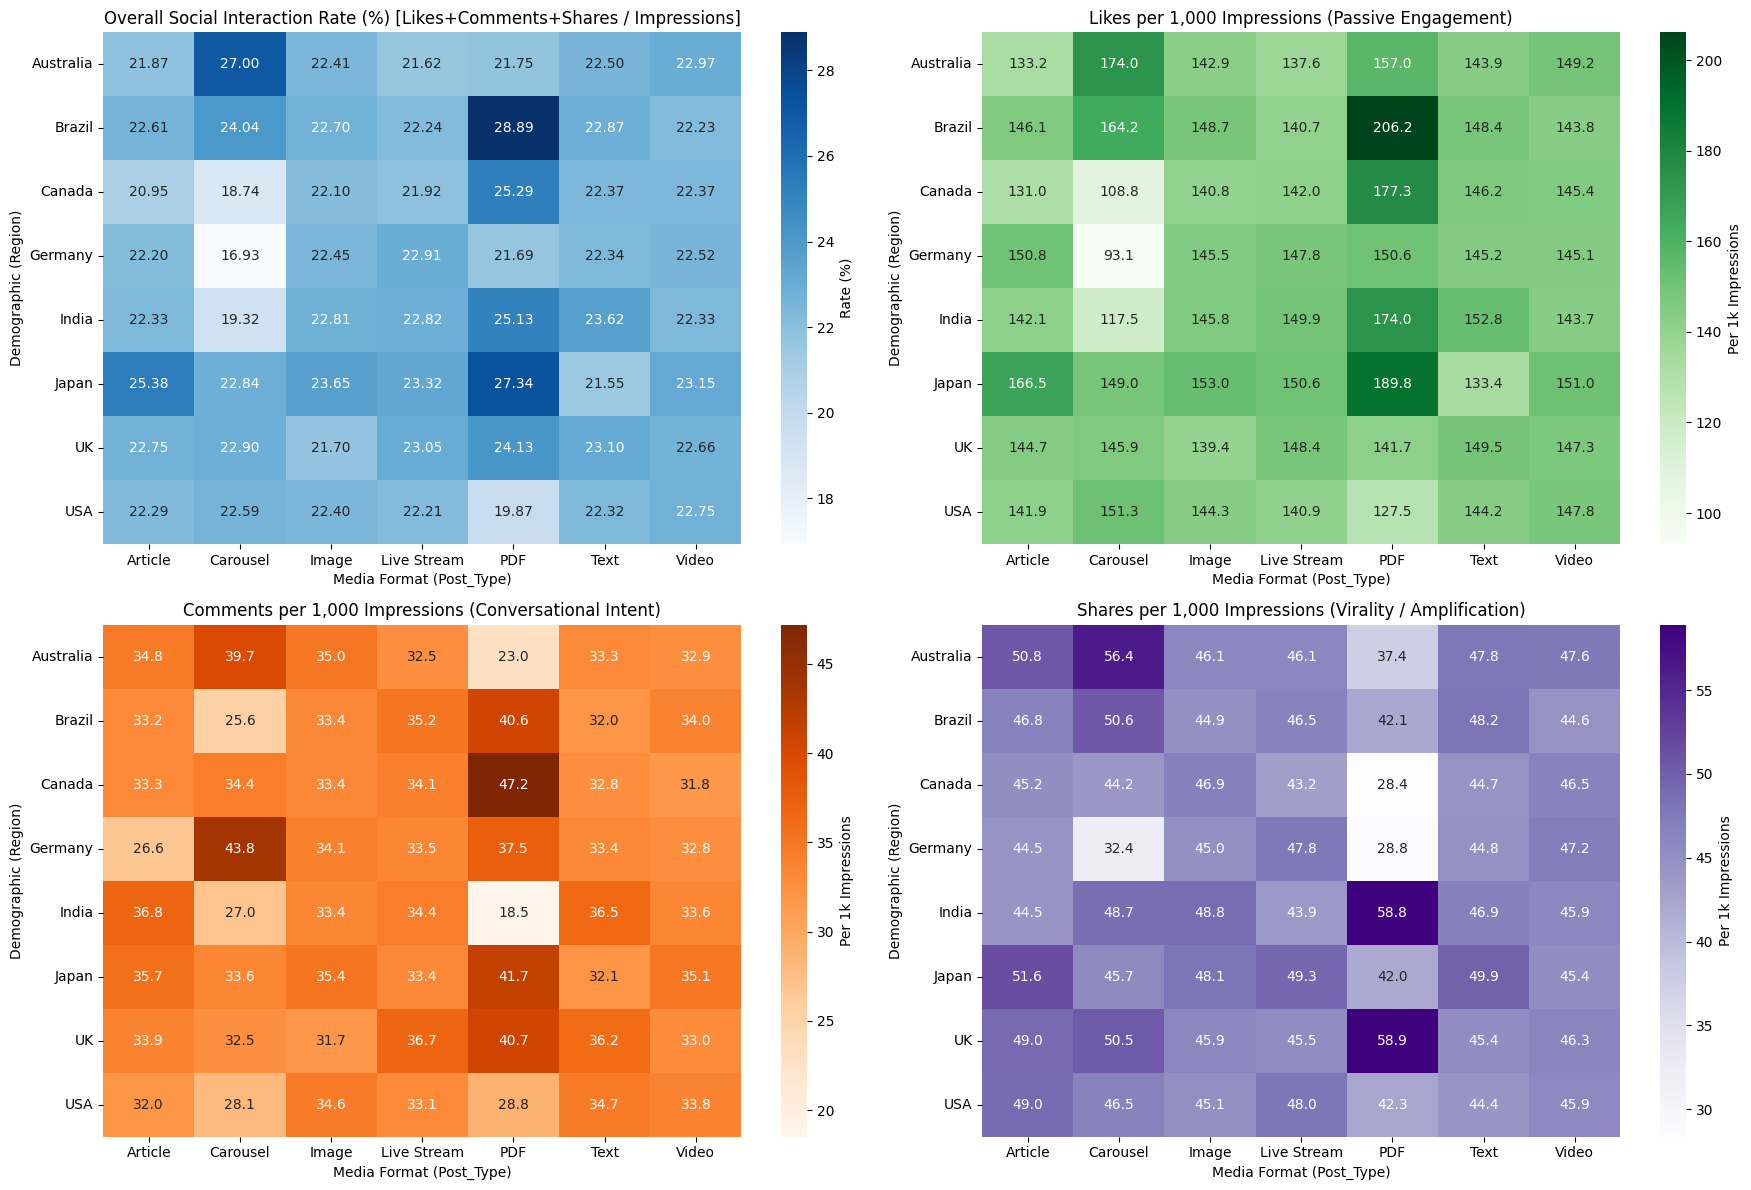

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Chart 1: Overall Social Interaction Rate (%)
sns.heatmap(
    pivot_interaction_rate, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    ax=axes[0, 0], 
    cbar_kws={'label': 'Rate (%)'}
)
axes[0, 0].set_title('Overall Social Interaction Rate (%) [Likes+Comments+Shares / Impressions]')
axes[0, 0].set_xlabel('Media Format (Post_Type)')
axes[0, 0].set_ylabel('Demographic (Region)')

# Chart 2: Likes per 1k Impressions (Passive Reactions)
sns.heatmap(
    pivot_likes, 
    annot=True, 
    fmt=".1f", 
    cmap="Greens", 
    ax=axes[0, 1], 
    cbar_kws={'label': 'Per 1k Impressions'}
)
axes[0, 1].set_title('Likes per 1,000 Impressions (Passive Engagement)')
axes[0, 1].set_xlabel('Media Format (Post_Type)')
axes[0, 1].set_ylabel('Demographic (Region)')

# Chart 3: Comments per 1k Impressions (Conversational Intent)
sns.heatmap(
    pivot_comments, 
    annot=True, 
    fmt=".1f", 
    cmap="Oranges", 
    ax=axes[1, 0], 
    cbar_kws={'label': 'Per 1k Impressions'}
)
axes[1, 0].set_title('Comments per 1,000 Impressions (Conversational Intent)')
axes[1, 0].set_xlabel('Media Format (Post_Type)')
axes[1, 0].set_ylabel('Demographic (Region)')

# Chart 4: Shares per 1k Impressions (Virality & Amplification)
sns.heatmap(
    pivot_shares, 
    annot=True, 
    fmt=".1f", 
    cmap="Purples", 
    ax=axes[1, 1], 
    cbar_kws={'label': 'Per 1k Impressions'}
)
axes[1, 1].set_title('Shares per 1,000 Impressions (Virality / Amplification)')
axes[1, 1].set_xlabel('Media Format (Post_Type)')
axes[1, 1].set_ylabel('Demographic (Region)')

plt.tight_layout()
plt.show()

In [ ]:


# 1. Ensure pure social interactions metric exists
df['Social_Interactions'] = df['Likes'] + df['Comments'] + df['Shares']

# Determine the exact column name used for hashtags in your dataframe
hashtag_col = 'Main_Hashtag' if 'Main_Hashtag' in df.columns else 'Hashtag'


# ==========================================
# QUESTION 1A: MEDIA FORMAT PREFERENCES (Video vs. Image/Carousel)
# ==========================================

geo_format = df.groupby(['Region', 'Post_Type']).agg(
    Post_Count=('Post_Type', 'count'),
    Total_Impressions=('Impressions', 'sum'),
    Total_Social_Interactions=('Social_Interactions', 'sum')
).reset_index()

geo_format['Social_Interaction_Rate_%'] = (
    geo_format['Total_Social_Interactions'] / geo_format['Total_Impressions']
) * 100

# Pivot matrices
pivot_format_volume = pd.crosstab(df['Region'], df['Post_Type'], normalize='index') * 100
pivot_format_rate = geo_format.pivot(index='Region', columns='Post_Type', values='Social_Interaction_Rate_%')


# ==========================================
# QUESTION 1B: THEME PREFERENCES (Educational vs. Entertainment)
# ==========================================

geo_theme = df.groupby(['Region', 'Content_Type']).agg(
    Post_Count=('Content_Type', 'count'),
    Total_Impressions=('Impressions', 'sum'),
    Total_Social_Interactions=('Social_Interactions', 'sum')
).reset_index()

geo_theme['Social_Interaction_Rate_%'] = (
    geo_theme['Total_Social_Interactions'] / geo_theme['Total_Impressions']
) * 100

# Pivot matrices
pivot_theme_volume = pd.crosstab(df['Region'], df['Content_Type'], normalize='index') * 100
pivot_theme_rate = geo_theme.pivot(index='Region', columns='Content_Type', values='Social_Interaction_Rate_%')


# ==========================================
# QUESTION 2: HASHTAG EFFECTIVENESS BY REGION
# ==========================================

geo_hashtag = df.groupby(['Region', hashtag_col]).agg(
    Post_Count=(hashtag_col, 'count'),
    Total_Impressions=('Impressions', 'sum'),
    Total_Social_Interactions=('Social_Interactions', 'sum'),
    Avg_Interactions_Per_Post=('Social_Interactions', 'mean')
).reset_index()

geo_hashtag['Social_Interaction_Rate_%'] = (
    geo_hashtag['Total_Social_Interactions'] / geo_hashtag['Total_Impressions']
) * 100

pivot_hashtag_rate = geo_hashtag.pivot(index='Region', columns=hashtag_col, values='Social_Interaction_Rate_%')

print("--- 1. Social Interaction Rate (%) by Media Format Across Regions ---")
print(pivot_format_rate.round(2))

print("\n--- 2. Social Interaction Rate (%) by Content Theme Across Regions ---")
print(pivot_theme_rate.round(2))

print(f"\n--- 3. Social Interaction Rate (%) by Hashtags Across Regions ---")
print(pivot_hashtag_rate.round(2))

--- 1. Social Interaction Rate (%) by Media Format Across Regions ---
Post_Type  Article  Carousel  Image  Live Stream   PDF  Text  Video
Region                                                             
Australia    21.87     27.00  22.41        21.62 21.75 22.50  22.97
Brazil       22.61     24.04  22.70        22.24 28.89 22.87  22.23
Canada       20.95     18.74  22.10        21.92 25.29 22.37  22.37
Germany      22.20     16.93  22.45        22.91 21.69 22.34  22.52
India        22.33     19.32  22.81        22.82 25.13 23.62  22.33
Japan        25.38     22.84  23.65        23.32 27.34 21.55  23.15
UK           22.75     22.90  21.70        23.05 24.13 23.10  22.66
USA          22.29     22.59  22.40        22.21 19.87 22.32  22.75

--- 2. Social Interaction Rate (%) by Content Theme Across Regions ---
Content_Type  Organic  Sponsored
Region                          
Australia       22.69      23.23
Brazil          22.38      22.14
Canada          22.08      22.80
Germany      

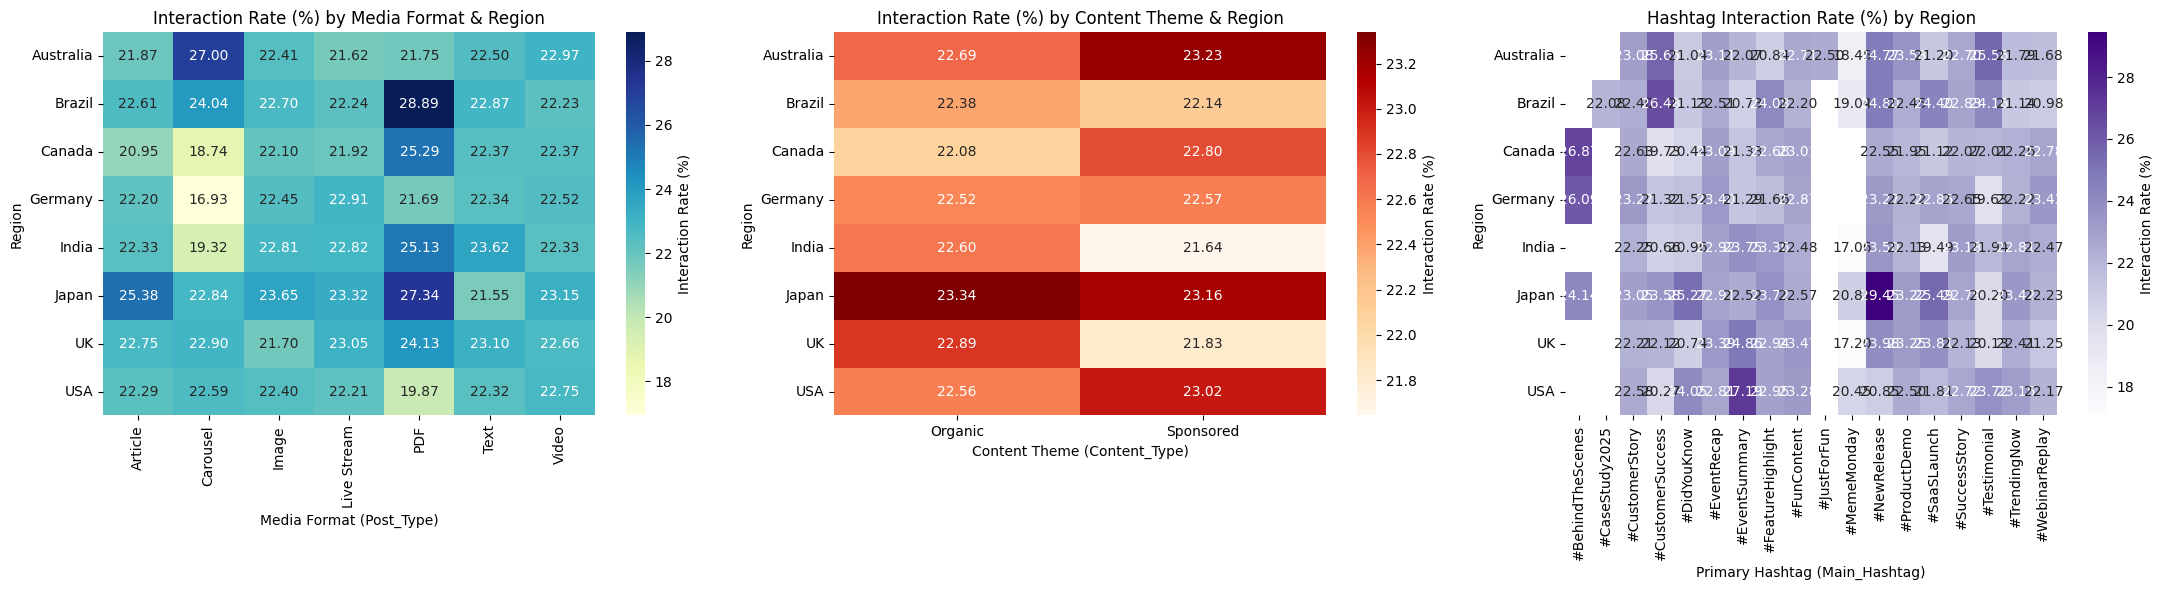

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Heatmap 1: Format Preferences (Video vs. Image/Carousel)
sns.heatmap(
    pivot_format_rate, 
    annot=True, 
    fmt=".2f", 
    cmap="YlGnBu", 
    ax=axes[0],
    cbar_kws={'label': 'Interaction Rate (%)'}
)
axes[0].set_title('Interaction Rate (%) by Media Format & Region')
axes[0].set_xlabel('Media Format (Post_Type)')
axes[0].set_ylabel('Region')

# Heatmap 2: Theme Preferences (Educational vs. Entertainment)
sns.heatmap(
    pivot_theme_rate, 
    annot=True, 
    fmt=".2f", 
    cmap="OrRd", 
    ax=axes[1],
    cbar_kws={'label': 'Interaction Rate (%)'}
)
axes[1].set_title('Interaction Rate (%) by Content Theme & Region')
axes[1].set_xlabel('Content Theme (Content_Type)')
axes[1].set_ylabel('Region')

# Heatmap 3: Primary Hashtag Effectiveness
sns.heatmap(
    pivot_hashtag_rate, 
    annot=True, 
    fmt=".2f", 
    cmap="Purples", 
    ax=axes[2],
    cbar_kws={'label': 'Interaction Rate (%)'}
)
axes[2].set_title(f'Hashtag Interaction Rate (%) by Region')
axes[2].set_xlabel(f'Primary Hashtag ({hashtag_col})')
axes[2].set_ylabel('Region')

plt.tight_layout()
plt.show()

In [ ]:


# Ensure pure social interactions metric exists
df['Social_Interactions'] = df['Likes'] + df['Comments'] + df['Shares']

# Identify hashtag column name
hashtag_col = 'Main_Hashtag' if 'Main_Hashtag' in df.columns else 'Hashtag'

# 1. Aggregate metrics by Region and Hashtag
geo_hashtag_perf = df.groupby(['Region', hashtag_col]).agg(
    Post_Count=(hashtag_col, 'count'),
    Total_Impressions=('Impressions', 'sum'),
    Total_Social_Interactions=('Social_Interactions', 'sum')
).reset_index()

# 2. Compute true weighted interaction rate (%)
geo_hashtag_perf['Social_Interaction_Rate_%'] = (
    geo_hashtag_perf['Total_Social_Interactions'] / geo_hashtag_perf['Total_Impressions']
) * 100

# Optional: Filter out hashtags with too few posts (e.g., at least 5 posts in that region)
# geo_hashtag_perf = geo_hashtag_perf[geo_hashtag_perf['Post_Count'] >= 5]

# 3. Extract the #1 top-performing hashtag per region
top_hashtag_per_region = (
    geo_hashtag_perf.sort_values(by=['Region', 'Social_Interaction_Rate_%'], ascending=[True, False])
    .groupby('Region')
    .first()
    .reset_index()
)

print("--- 🏆 Top #1 Primary Hashtag by Region (by Interaction Rate %) ---")
print(top_hashtag_per_region[['Region', hashtag_col, 'Post_Count', 'Social_Interaction_Rate_%']])

--- 🏆 Top #1 Primary Hashtag by Region (by Interaction Rate %) ---
      Region      Main_Hashtag  Post_Count  Social_Interaction_Rate_%
0  Australia  #CustomerSuccess          15                      25.65
1     Brazil  #CustomerSuccess           9                      26.48
2     Canada  #BehindTheScenes           1                      26.87
3    Germany  #BehindTheScenes           1                      26.09
4      India     #EventSummary           4                      23.75
5      Japan       #NewRelease           3                      29.45
6         UK     #EventSummary           3                      24.86
7        USA     #EventSummary           4                      27.19


In [ ]:
# 1. Convert date column to pandas datetime format
df['Post_Date'] = pd.to_datetime(df['Post_Date'])

# 2. Extract the full day name (Monday, Tuesday, etc.)
df['Day_Name'] = df['Post_Date'].dt.day_name()

# Check the new column
print(df[['Post_Date', 'Day_Name']].head())

   Post_Date   Day_Name
0 2024-03-14   Thursday
1 2024-04-24  Wednesday
2 2024-12-01     Sunday
3 2024-07-07     Sunday
4 2024-01-10  Wednesday


In [ ]:


# Ensure Day_Name exists or is ordered logically
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 1. Aggregate metrics by Day of Week
day_efficiency = df.groupby('Day_Name').agg(
    Total_Posts=('Day_Name', 'count'),
    Total_Impressions=('Impressions', 'sum'),
    Avg_Impressions=('Impressions', 'mean'),
    Total_Dataset_Engagement=('Engagement', 'sum'),
    Avg_Dataset_Engagement=('Engagement', 'mean')
).reindex(day_order).reset_index()

# 2. Compute true weighted Dataset Engagement Rate (%)
day_efficiency['Dataset_Engagement_Rate_%'] = (
    day_efficiency['Total_Dataset_Engagement'] / day_efficiency['Total_Impressions']
) * 100

print("--- Day of Week Efficiency Overview ---")
print(day_efficiency[[
    'Day_Name', 'Total_Posts', 'Total_Impressions', 
    'Avg_Impressions', 'Total_Dataset_Engagement', 
    'Dataset_Engagement_Rate_%'
]])

--- Day of Week Efficiency Overview ---
    Day_Name  Total_Posts  Total_Impressions  Avg_Impressions  \
0     Monday          793          794828828       1002306.21   
1    Tuesday          785          794639877       1012280.10   
2  Wednesday          846          906843852       1071919.45   
3   Thursday          822          808445565        983510.42   
4     Friday          778          804127584       1033583.01   
5   Saturday          799          864413272       1081868.93   
6     Sunday          774          792449325       1023836.34   

   Total_Dataset_Engagement  Dataset_Engagement_Rate_%  
0                  89769636                      11.29  
1                  87456626                      11.01  
2                 100405596                      11.07  
3                  89845350                      11.11  
4                  90286025                      11.23  
5                  97835985                      11.32  
6                  90775992             

C:\Users\salma\AppData\Local\Temp\ipykernel_22148\1119031075.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\salma\AppData\Local\Temp\ipykernel_22148\1119031075.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


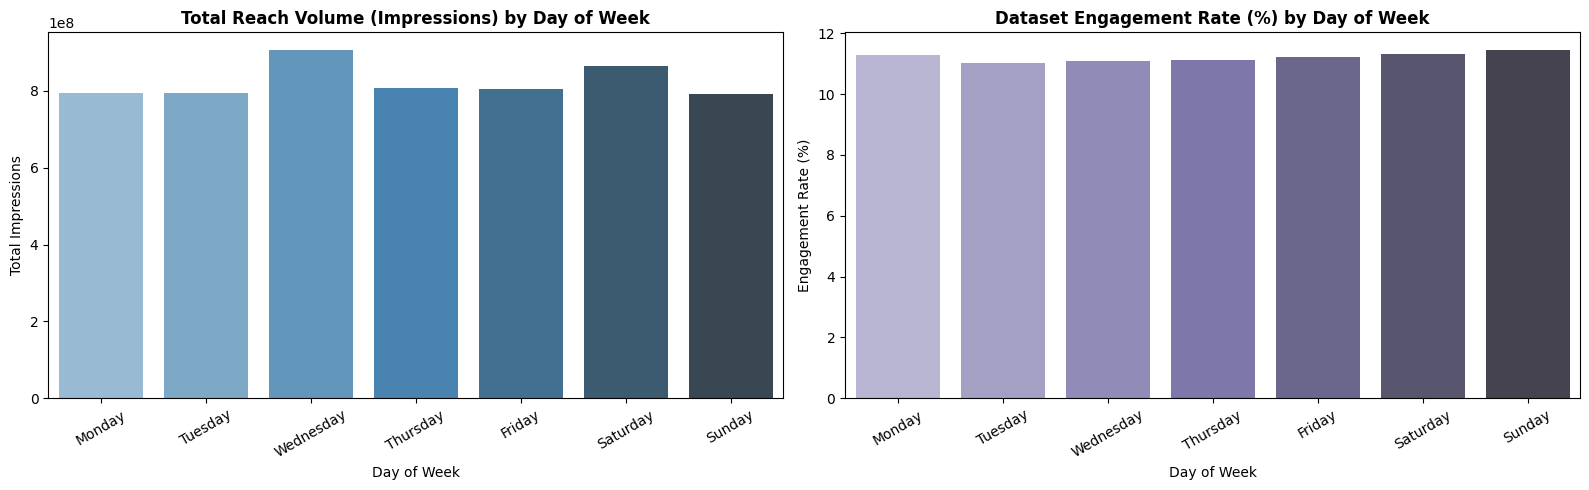

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Total Reach (Impressions Volume) by Day of Week
sns.barplot(
    data=day_efficiency,
    x='Day_Name',
    y='Total_Impressions',
    ax=axes[0],
    palette='Blues_d'
)
axes[0].set_title('Total Reach Volume (Impressions) by Day of Week', fontweight='bold')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Total Impressions')
axes[0].tick_params(axis='x', rotation=30)

# Plot 2: Dataset Weighted Engagement Rate (%) by Day of Week
sns.barplot(
    data=day_efficiency,
    x='Day_Name',
    y='Dataset_Engagement_Rate_%',
    ax=axes[1],
    palette='Purples_d'
)
axes[1].set_title('Dataset Engagement Rate (%) by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Engagement Rate (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
df['Post_Published_At'] = pd.to_datetime(df['Post_Published_At'])

df['Post_Hour'] = df['Post_Published_At'].dt.hour

In [ ]:
hour_efficiency = df.groupby('Post_Hour').agg(
    Total_Posts=('Post_ID', 'count'),
    Total_Impressions=('Impressions', 'sum'),
    Total_Engagement=('Engagement', 'sum'),
    Avg_Impressions=('Impressions', 'mean'),
    Avg_Engagement=('Engagement', 'mean')
).reset_index()

# Weighted engagement rate
hour_efficiency['Engagement_Rate_%'] = (
    hour_efficiency['Total_Engagement'] /
    hour_efficiency['Total_Impressions']
) * 100

# Make sure hours appear from 0 → 23
hour_efficiency = (
    hour_efficiency
    .set_index('Post_Hour')
    .reindex(range(24))
    .reset_index()
)

print(hour_efficiency.round(2))

    Post_Hour  Total_Posts  Total_Impressions  Total_Engagement  \
0           0          NaN                NaN               NaN   
1           1          NaN                NaN               NaN   
2           2          NaN                NaN               NaN   
3           3          NaN                NaN               NaN   
4           4          NaN                NaN               NaN   
5           5          NaN                NaN               NaN   
6           6          NaN                NaN               NaN   
7           7          NaN                NaN               NaN   
8           8       194.00       221811715.00       26497702.00   
9           9       212.00       228627553.00       24047963.00   
10         10       731.00       746704271.00       80775876.00   
11         11       749.00       784195200.00       87801362.00   
12         12       754.00       773298318.00       85236015.00   
13         13       169.00       171196213.00       19011945.0

In [ ]:
print(df['Post_Published_At'].min())
print(df['Post_Published_At'].max())

2024-01-01 10:18:00
2025-05-01 17:05:00


In [ ]:
print(
    (df['Post_Published_At'].dt.hour == df['Post_Hour']).value_counts()
)

True    5597
Name: count, dtype: int64


In [ ]:
print(
    df['Post_Published_At'].dt.hour
    .value_counts()
    .sort_index()
)

Post_Published_At
8     194
9     212
10    731
11    749
12    754
13    169
14    167
15    758
16    766
17    743
18    190
19    164
Name: count, dtype: int64


In [ ]:
hour_efficiency = df.groupby('Post_Hour').agg(
    Total_Posts=('Post_ID', 'count'),
    Total_Impressions=('Impressions', 'sum'),
    Total_Engagement=('Engagement', 'sum'),
    Avg_Impressions=('Impressions', 'mean'),
    Avg_Engagement=('Engagement', 'mean')
).reset_index()

hour_efficiency['Engagement_Rate_%'] = (
    hour_efficiency['Total_Engagement'] /
    hour_efficiency['Total_Impressions']
) * 100

print(
    hour_efficiency[
        ['Post_Hour', 'Total_Posts', 'Engagement_Rate_%']
    ].round(2)
)

    Post_Hour  Total_Posts  Engagement_Rate_%
0           8          194              11.95
1           9          212              10.52
2          10          731              10.82
3          11          749              11.20
4          12          754              11.02
5          13          169              11.11
6          14          167              11.40
7          15          758              11.28
8          16          766              11.51
9          17          743              11.34
10         18          190              11.86
11         19          164              10.77


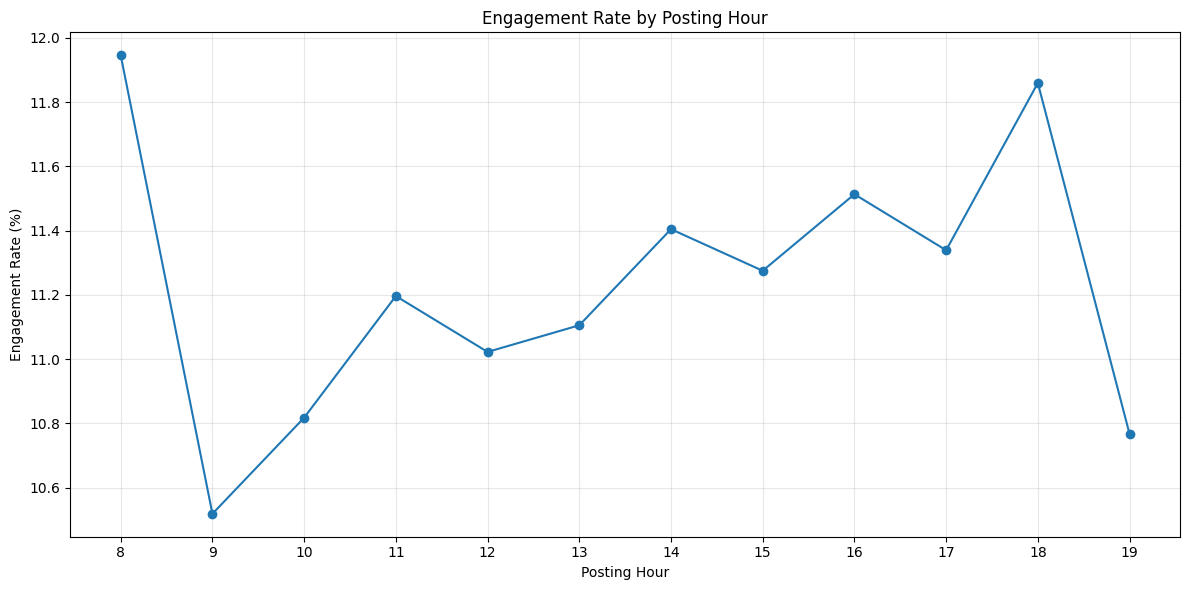

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    hour_efficiency['Post_Hour'],
    hour_efficiency['Engagement_Rate_%'],
    marker='o'
)

plt.title('Engagement Rate by Posting Hour')
plt.xlabel('Posting Hour')
plt.ylabel('Engagement Rate (%)')
plt.xticks(hour_efficiency['Post_Hour'])
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

# Ensure explicit interaction metric exists
df['Social_Interactions'] = df['Likes'] + df['Comments'] + df['Shares']

# Define logical day order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 1. Group by Day_Name and Post_Hour
matrix_agg = df.groupby(['Day_Name', 'Post_Hour']).agg(
    Post_Count=('Post_Hour', 'count'),
    Total_Impressions=('Impressions', 'sum'),
    Total_Social_Interactions=('Social_Interactions', 'sum'),
    Total_Dataset_Engagement=('Engagement', 'sum')
).reset_index()

# 2. Compute weighted interaction rates (%)
matrix_agg['Social_Interaction_Rate_%'] = (
    matrix_agg['Total_Social_Interactions'] / matrix_agg['Total_Impressions']
) * 100

matrix_agg['Dataset_Engagement_Rate_%'] = (
    matrix_agg['Total_Dataset_Engagement'] / matrix_agg['Total_Impressions']
) * 100

# 3. Filter out rare slots (e.g., at least 3 posts) to avoid noise from single viral outliers
# matrix_agg = matrix_agg[matrix_agg['Post_Count'] >= 3]

# 4. Find the Absolute Top 5 Peak Combinations
top_5_social_slots = matrix_agg.sort_values(
    by='Social_Interaction_Rate_%', ascending=False
).head(5)

top_5_dataset_slots = matrix_agg.sort_values(
    by='Dataset_Engagement_Rate_%', ascending=False
).head(5)

print("--- 🏆 Top 5 Slots by Explicit Social Interaction Rate (%) ---")
print(top_5_social_slots[['Day_Name', 'Post_Hour', 'Post_Count', 'Total_Impressions', 'Social_Interaction_Rate_%']])

print("\n--- 🏆 Top 5 Slots by Dataset Engagement Rate (%) ---")
print(top_5_dataset_slots[['Day_Name', 'Post_Hour', 'Post_Count', 'Total_Impressions', 'Dataset_Engagement_Rate_%']])

--- 🏆 Top 5 Slots by Explicit Social Interaction Rate (%) ---
    Day_Name  Post_Hour  Post_Count  Total_Impressions  \
36    Sunday          8          22           19915335   
12    Monday          8          18           16411835   
24  Saturday          8          35           42116803   
44    Sunday         16         106           95471422   
6     Friday         14          20           29824885   

    Social_Interaction_Rate_%  
36                      25.13  
12                      24.47  
24                      24.21  
44                      24.10  
6                       23.92  

--- 🏆 Top 5 Slots by Dataset Engagement Rate (%) ---
    Day_Name  Post_Hour  Post_Count  Total_Impressions  \
5     Friday         13          20           15134280   
47    Sunday         19          25           27901135   
65   Tuesday         13          25           20592289   
10    Friday         18          32           40946434   
30  Saturday         14          29           2927244

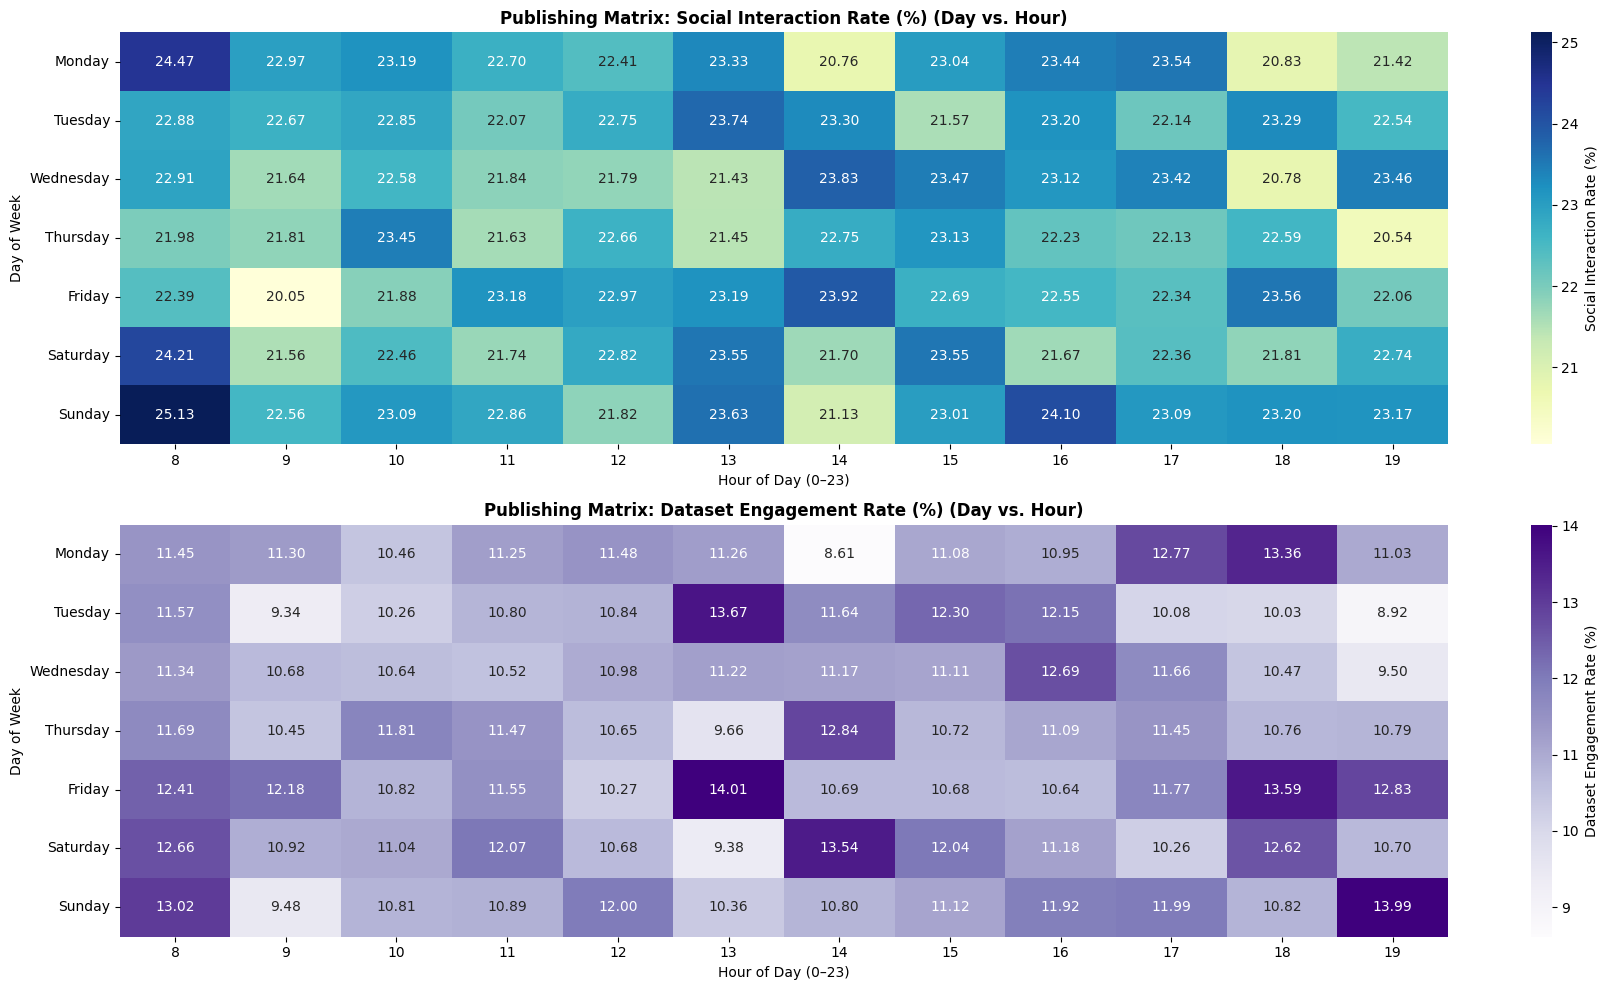

In [ ]:
# Pivot into Day x Hour matrices
pivot_social = matrix_agg.pivot(
    index='Day_Name', columns='Post_Hour', values='Social_Interaction_Rate_%'
).reindex(day_order)

pivot_dataset = matrix_agg.pivot(
    index='Day_Name', columns='Post_Hour', values='Dataset_Engagement_Rate_%'
).reindex(day_order)

fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# Heatmap 1: Explicit Social Interaction Rate (%)
sns.heatmap(
    pivot_social,
    cmap='YlGnBu',
    annot=True,
    fmt='.2f',
    cbar_kws={'label': 'Social Interaction Rate (%)'},
    ax=axes[0]
)
axes[0].set_title('Publishing Matrix: Social Interaction Rate (%) (Day vs. Hour)', fontweight='bold')
axes[0].set_xlabel('Hour of Day (0–23)')
axes[0].set_ylabel('Day of Week')

# Heatmap 2: Dataset Engagement Rate (%)
sns.heatmap(
    pivot_dataset,
    cmap='Purples',
    annot=True,
    fmt='.2f',
    cbar_kws={'label': 'Dataset Engagement Rate (%)'},
    ax=axes[1]
)
axes[1].set_title('Publishing Matrix: Dataset Engagement Rate (%) (Day vs. Hour)', fontweight='bold')
axes[1].set_xlabel('Hour of Day (0–23)')
axes[1].set_ylabel('Day of Week')

plt.tight_layout()
plt.show()

In [ ]:


# Identify column names in your dataset
platform_col = 'Platform' if 'Platform' in df.columns else 'Social_Platform'
views_col = 'Views' if 'Views' in df.columns else 'Video_Views'

# Aggregate Reach Metrics by Platform
platform_reach = df.groupby(platform_col).agg(
    Total_Posts=(platform_col, 'count'),
    Total_Impressions=('Impressions', 'sum'),
    Total_Views=(views_col, 'sum'),
    Avg_Impressions_Per_Post=('Impressions', 'mean'),
    Avg_Views_Per_Post=(views_col, 'mean')
).reset_index()

# Sort by Total Impressions descending
platform_reach = platform_reach.sort_values(by='Total_Impressions', ascending=False)

print("--- 📊 Reach Summary by Social Platform ---")
print(platform_reach[[
    platform_col, 'Total_Posts', 'Total_Impressions', 
    'Total_Views', 'Avg_Impressions_Per_Post', 'Avg_Views_Per_Post'
]])

--- 📊 Reach Summary by Social Platform ---
    Platform  Total_Posts  Total_Impressions  Total_Views  \
5    YouTube         1320         1352039371   1127851535   
3     TikTok         1257         1307696351   1087939789   
4      X.com         1201         1197901205    999657152   
1  Instagram          998         1181863961    984925751   
2   LinkedIn          522          407628877    339946827   
0   Facebook          299          318618538    265320234   

   Avg_Impressions_Per_Post  Avg_Views_Per_Post  
5                1024272.25           854432.98  
3                1040331.23           865505.00  
4                 997419.82           832354.00  
1                1184232.43           986899.55  
2                 780898.23           651239.13  
0                1065613.84           887358.64  


C:\Users\salma\AppData\Local\Temp\ipykernel_22148\2652646656.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\salma\AppData\Local\Temp\ipykernel_22148\2652646656.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\salma\AppData\Local\Temp\ipykernel_22148\2652646656.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


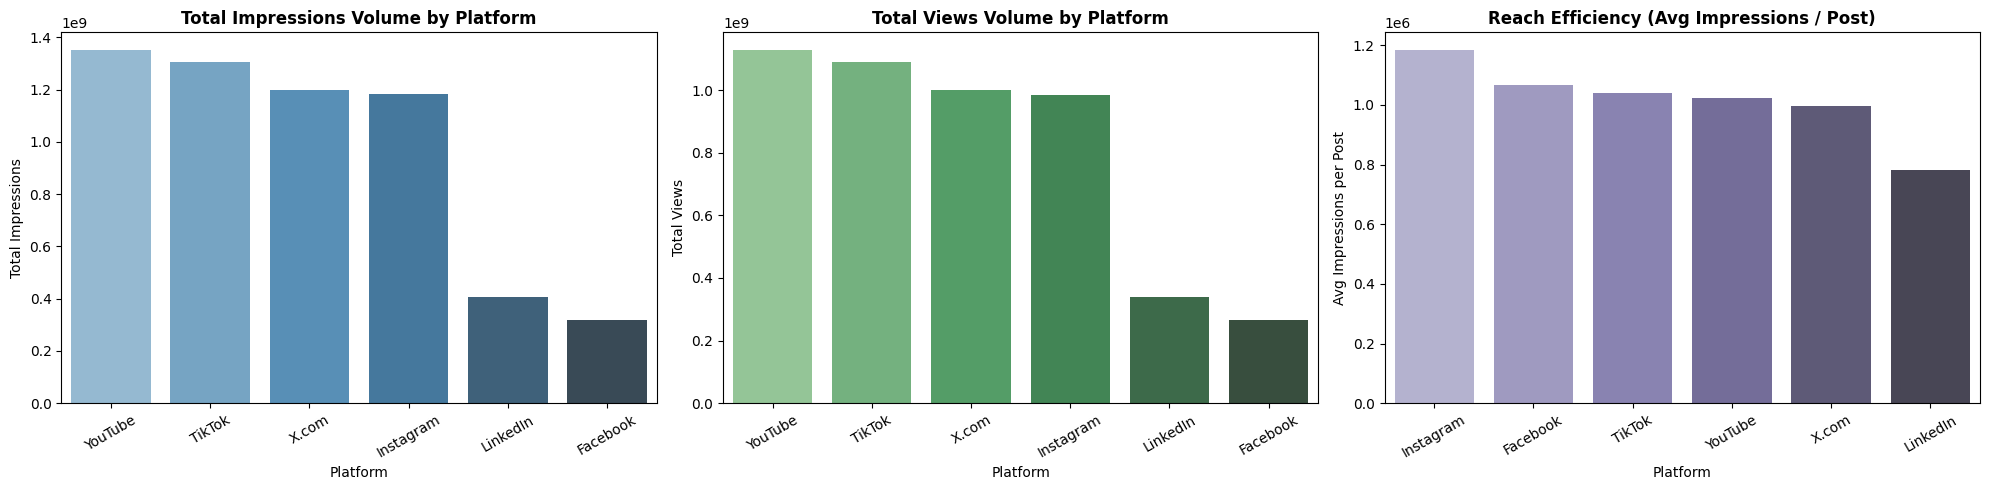

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: Total Impressions by Platform
sns.barplot(
    data=platform_reach,
    x=platform_col,
    y='Total_Impressions',
    palette='Blues_d',
    ax=axes[0]
)
axes[0].set_title('Total Impressions Volume by Platform', fontweight='bold')
axes[0].set_xlabel('Platform')
axes[0].set_ylabel('Total Impressions')
axes[0].tick_params(axis='x', rotation=30)

# Plot 2: Total Views by Platform
sns.barplot(
    data=platform_reach.sort_values(by='Total_Views', ascending=False),
    x=platform_col,
    y='Total_Views',
    palette='Greens_d',
    ax=axes[1]
)
axes[1].set_title('Total Views Volume by Platform', fontweight='bold')
axes[1].set_xlabel('Platform')
axes[1].set_ylabel('Total Views')
axes[1].tick_params(axis='x', rotation=30)

# Plot 3: Average Impressions Per Post (Reach Efficiency)
sns.barplot(
    data=platform_reach.sort_values(by='Avg_Impressions_Per_Post', ascending=False),
    x=platform_col,
    y='Avg_Impressions_Per_Post',
    palette='Purples_d',
    ax=axes[2]
)
axes[2].set_title('Reach Efficiency (Avg Impressions / Post)', fontweight='bold')
axes[2].set_xlabel('Platform')
axes[2].set_ylabel('Avg Impressions per Post')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
pd.set_option('display.max_columns', None)

df.head()

,Post_ID,Platform,Content_Type,Content_Category,Post_Type,Region,Longitude,Latitude,Engagement,Views,Likes,Shares,Comments,Engagement_Rate,Impressions,Video_Views,Live_Stream_Views,Clicks,Click_Through_Rate,Main_Hashtag,Post_Published_At,Post_Date,Post_Hour,Engagement_Level,Day,Month,Year,Social_Interactions,Spatial_Cluster,Day_Name
0,Post_1,TikTok,Organic,Product Promotion,Video,UK,-3.44,55.38,54510,599342,125741,35920,15727,0.09,677975,465645,0,16813.00,0.02,#FeatureHighlight,2024-03-14 15:42:00,2024-03-14,15,Low,Thursday,March,2024,177388,2,Thursday
1,Post_2,Instagram,Organic,Product Promotion,Video,India,78.96,20.59,259440,1896301,206151,139015,83521,0.14,2354474,1896301,0,NaN,NaN,#ProductDemo,2024-04-24 12:02:00,2024-04-24,12,Medium,Wednesday,April,2024,428687,3,Wednesday
2,Post_3,X.com,Organic,Entertainment,Text,Brazil,-51.93,-14.23,14182,253052,32206,9912,8140,0.06,304915,0,0,NaN,NaN,#MemeMonday,2024-12-01 10:02:00,2024-12-01,10,Low,Sunday,December,2024,50258,4,Sunday
3,Post_4,Instagram,Organic,Entertainment,Carousel,Australia,133.78,-25.27,49137,735640,121227,32781,32716,0.07,829727,0,0,NaN,NaN,#JustForFun,2024-07-07 12:59:00,2024-07-07,12,Low,Sunday,July,2024,186724,0,Sunday
4,Post_5,TikTok,Organic,Educational,Video,Brazil,-51.93,-14.23,20832,77358,13027,5357,2165,0.27,93049,72707,0,1944.00,0.02,#CaseStudy2025,2024-01-10 11:28:00,2024-01-10,11,High,Wednesday,January,2024,20549,4,Wednesday


In [ ]:

# Ensure explicit social interactions metric exists
df['Social_Interactions'] = df['Likes'] + df['Comments'] + df['Shares']

# Identify platform column name in your dataframe
platform_col = 'Platform' if 'Platform' in df.columns else 'Social_Platform'

# 1. Aggregate Reach & Engagement Metrics by Platform
platform_eff = (
    df.groupby(platform_col)
    .agg(
        Total_Posts=(platform_col, 'count'),
        Total_Impressions=('Impressions', 'sum'),
        Total_Social_Interactions=('Social_Interactions', 'sum'),
        Total_Dataset_Engagement=('Engagement', 'sum'),
    )
    .reset_index()
)

# 2. Compute Weighted Engagement Rates (%) [Engagement / Impressions * 100]
platform_eff['Social_Interaction_Rate_%'] = (
    platform_eff['Total_Social_Interactions'] / platform_eff['Total_Impressions']
) * 100

platform_eff['Dataset_Engagement_Rate_%'] = (
    platform_eff['Total_Dataset_Engagement'] / platform_eff['Total_Impressions']
) * 100

# 3. Sort by Dataset Engagement Rate
platform_eff = platform_eff.sort_values(
    by='Dataset_Engagement_Rate_%', ascending=False
)

print('--- 🏆 Platform Engagement Efficiency Ranking ---')
print(
    platform_eff[[
        platform_col,
        'Total_Posts',
        'Total_Impressions',
        'Total_Social_Interactions',
        'Social_Interaction_Rate_%',
        'Total_Dataset_Engagement',
        'Dataset_Engagement_Rate_%',
    ]]
)

--- 🏆 Platform Engagement Efficiency Ranking ---
    Platform  Total_Posts  Total_Impressions  Total_Social_Interactions  \
1  Instagram          998         1181863961                  265516359   
3     TikTok         1257         1307696351                  299538058   
0   Facebook          299          318618538                   71180576   
5    YouTube         1320         1352039371                  304054963   
4      X.com         1201         1197901205                  270862327   
2   LinkedIn          522          407628877                   93041440   

   Social_Interaction_Rate_%  Total_Dataset_Engagement  \
1                      22.47                 134738386   
3                      22.91                 146646344   
0                      22.34                  35701985   
5                      22.49                 151399907   
4                      22.61                 133273396   
2                      22.83                  44615192   

   Dataset_Engagem

C:\Users\salma\AppData\Local\Temp\ipykernel_22148\4284601132.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\salma\AppData\Local\Temp\ipykernel_22148\4284601132.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


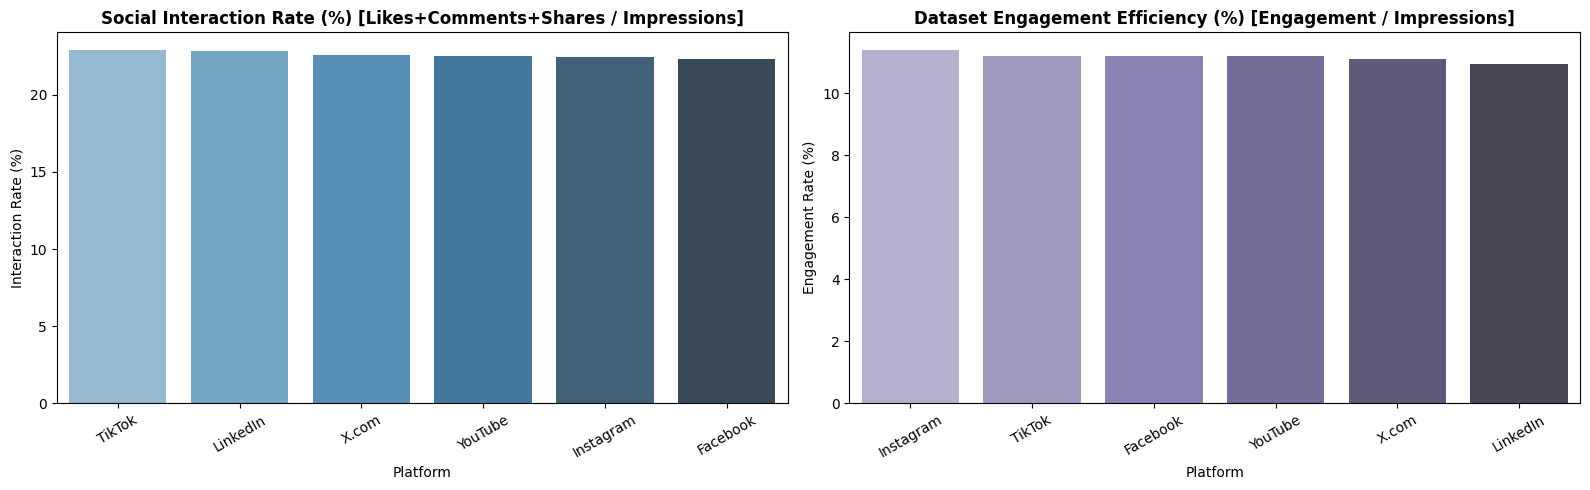

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: Explicit Social Interaction Rate (%)
sns.barplot(
    data=platform_eff.sort_values(
        by='Social_Interaction_Rate_%', ascending=False
    ),
    x=platform_col,
    y='Social_Interaction_Rate_%',
    palette='Blues_d',
    ax=axes[0],
)
axes[0].set_title(
    'Social Interaction Rate (%) [Likes+Comments+Shares / Impressions]',
    fontweight='bold',
)
axes[0].set_xlabel('Platform')
axes[0].set_ylabel('Interaction Rate (%)')
axes[0].tick_params(axis='x', rotation=30)

# Chart 2: Dataset Engagement Rate (%) [Engagement / Impressions]
sns.barplot(
    data=platform_eff,
    x=platform_col,
    y='Dataset_Engagement_Rate_%',
    palette='Purples_d',
    ax=axes[1],
)
axes[1].set_title(
    'Dataset Engagement Efficiency (%) [Engagement / Impressions]',
    fontweight='bold',
)
axes[1].set_xlabel('Platform')
axes[1].set_ylabel('Engagement Rate (%)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
# Convert to datetime format if needed (replace 'Post_Date' with your column name)
df['Post_Date'] = pd.to_datetime(df['Post_Date'])

# Extract Year-Month string (e.g., '2025-01', '2025-02') for strict chronological sorting
df['Year_Month'] = df['Post_Date'].dt.to_period('M').astype(str)

# Extract Month Name for seasonal analysis
df['Month_Name'] = df['Post_Date'].dt.month_name()

In [ ]:
# Ensure explicit social interactions metric exists
df['Social_Interactions'] = df['Likes'] + df['Comments'] + df['Shares']

# 1. Aggregate metrics by Year_Month
monthly_summary = (
    df.groupby('Year_Month')
    .agg(
        Total_Posts=('Year_Month', 'count'),
        Total_Impressions=('Impressions', 'sum'),
        Avg_Impressions_Per_Post=('Impressions', 'mean'),
        Total_Social_Interactions=('Social_Interactions', 'sum'),
        Total_Dataset_Engagement=('Engagement', 'sum'),
    )
    .reset_index()
)

# 2. Compute Weighted Efficiency Metrics (%) over time
monthly_summary['Social_Interaction_Rate_%'] = (
    monthly_summary['Total_Social_Interactions']
    / monthly_summary['Total_Impressions']
) * 100

monthly_summary['Dataset_Engagement_Rate_%'] = (
    monthly_summary['Total_Dataset_Engagement']
    / monthly_summary['Total_Impressions']
) * 100

print('--- 📈 Monthly Performance & Reach Trends ---')
print(
    monthly_summary[[
        'Year_Month',
        'Total_Posts',
        'Total_Impressions',
        'Total_Social_Interactions',
        'Social_Interaction_Rate_%',
        'Dataset_Engagement_Rate_%',
    ]]
)

--- 📈 Monthly Performance & Reach Trends ---
   Year_Month  Total_Posts  Total_Impressions  Total_Social_Interactions  \
0     2024-01          365          390130037                   88954547   
1     2024-02          297          336683950                   77752132   
2     2024-03          393          358618299                   79729909   
3     2024-04          353          327929790                   73075468   
4     2024-05          383          345400356                   78132382   
5     2024-06          365          381348633                   86534510   
6     2024-07          357          354247418                   80681276   
7     2024-08          350          379483732                   86433418   
8     2024-09          319          314212992                   70168226   
9     2024-10          337          363696114                   82486415   
10    2024-11          340          348522834                   77468416   
11    2024-12          344          3728900

C:\Users\salma\AppData\Local\Temp\ipykernel_22148\2858476970.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


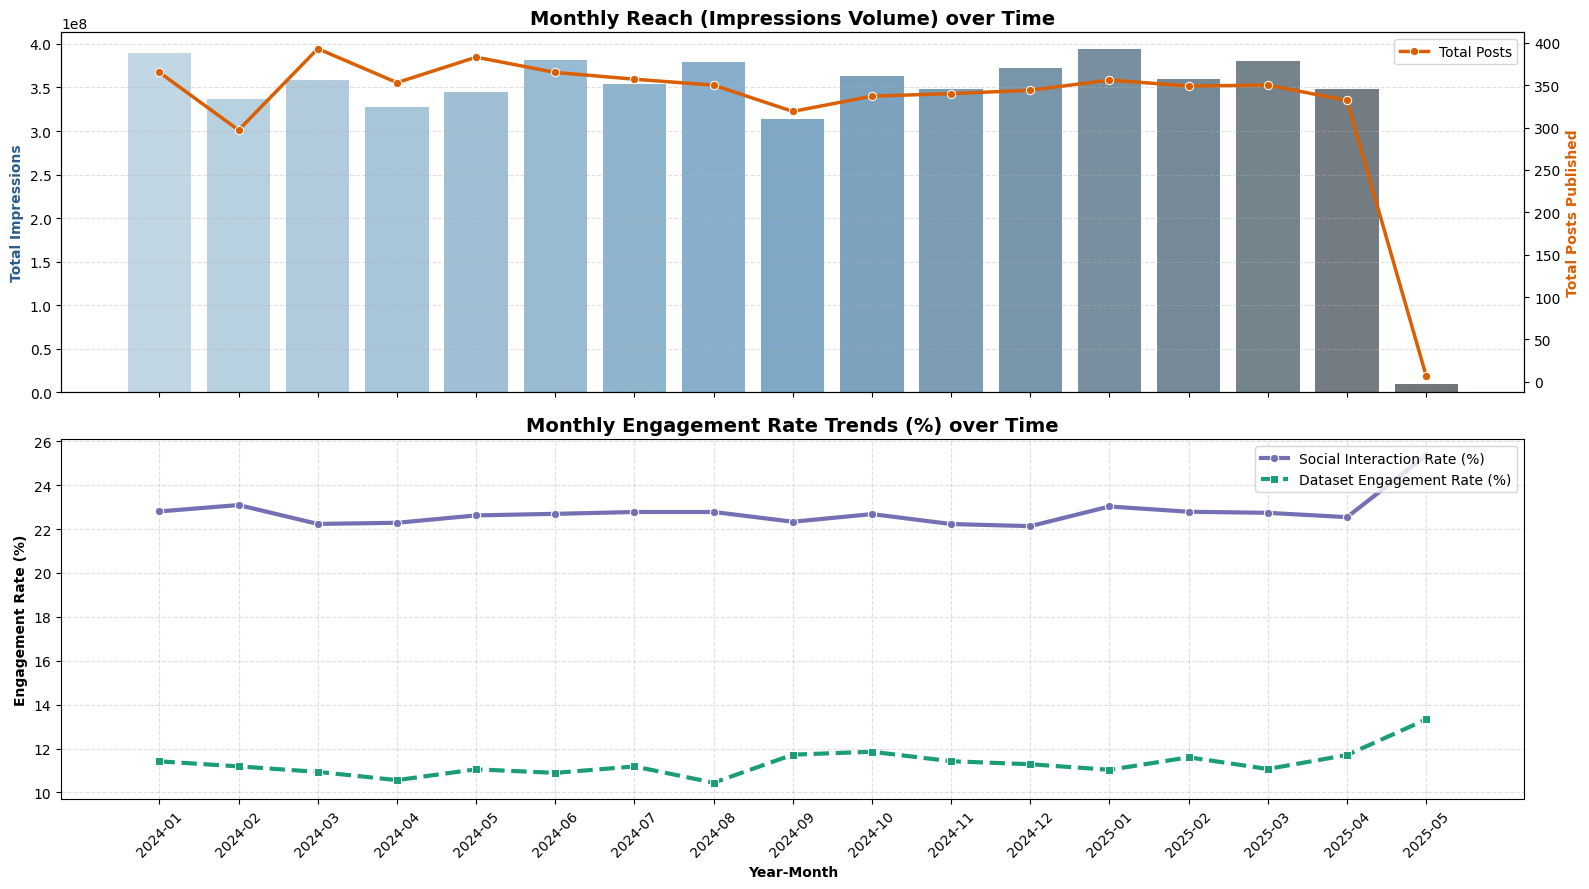

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# Plot 1: Monthly Reach (Impressions) & Publishing Volume
ax1 = axes[0]
sns.barplot(
    data=monthly_summary,
    x='Year_Month',
    y='Total_Impressions',
    palette='Blues_d',
    ax=ax1,
    alpha=0.7,
)
ax1.set_title(
    'Monthly Reach (Impressions Volume) over Time',
    fontweight='bold',
    fontsize=14,
)
ax1.set_ylabel('Total Impressions', fontweight='bold', color='#2b5c8f')
ax1.grid(True, linestyle='--', alpha=0.4, axis='y')

# Overlay Post Count on secondary Y-axis
ax1_twin = ax1.twinx()
sns.lineplot(
    data=monthly_summary,
    x=monthly_summary.index,
    y='Total_Posts',
    color='#d95f02',
    linewidth=2.5,
    marker='o',
    ax=ax1_twin,
    label='Total Posts',
)
ax1_twin.set_ylabel('Total Posts Published', fontweight='bold', color='#d95f02')

# Plot 2: Engagement Rate Trends (%) over Time
ax2 = axes[1]
sns.lineplot(
    data=monthly_summary,
    x=monthly_summary.index,
    y='Social_Interaction_Rate_%',
    marker='o',
    color='#7570b3',
    linewidth=3,
    label='Social Interaction Rate (%)',
    ax=ax2,
)
sns.lineplot(
    data=monthly_summary,
    x=monthly_summary.index,
    y='Dataset_Engagement_Rate_%',
    marker='s',
    color='#1b9e77',
    linewidth=3,
    linestyle='--',
    label='Dataset Engagement Rate (%)',
    ax=ax2,
)
ax2.set_title(
    'Monthly Engagement Rate Trends (%) over Time',
    fontweight='bold',
    fontsize=14,
)
ax2.set_xlabel('Year-Month', fontweight='bold')
ax2.set_ylabel('Engagement Rate (%)', fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.set_xticks(range(len(monthly_summary)))
ax2.set_xticklabels(monthly_summary['Year_Month'], rotation=45)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# Ensure date column is formatted
df['Post_Date'] = pd.to_datetime(df['Post_Date'])

# Create a Year-Week string (e.g., '2025-W12') for strict weekly aggregation
df['Year_Week'] =  (
    df['Post_Date'].dt.isocalendar().year.astype(str)
    + '-W'
    + df['Post_Date'].dt.isocalendar().week.astype(str).str.zfill(2)
)

# Ensure explicit social interactions metric exists
df['Social_Interactions'] = df['Likes'] + df['Comments'] + df['Shares']

# ==========================================
# 1. WEEKLY AGGREGATION
# ==========================================
weekly_summary = (
    df.groupby('Year_Week')
    .agg(
        Posts_Per_Week=('Year_Week', 'count'),
        Total_Impressions=('Impressions', 'sum'),
        Avg_Impressions_Per_Post=('Impressions', 'mean'),
        Total_Social_Interactions=('Social_Interactions', 'sum'),
        Total_Dataset_Engagement=('Engagement', 'sum'),
        Avg_Dataset_Engagement_Per_Post=('Engagement', 'mean'),
    )
    .reset_index()
)

# Compute true weighted efficiency metrics (%)
weekly_summary['Social_Interaction_Rate_%'] = (
    weekly_summary['Total_Social_Interactions']
    / weekly_summary['Total_Impressions']
) * 100

weekly_summary['Dataset_Engagement_Rate_%'] = (
    weekly_summary['Total_Dataset_Engagement']
    / weekly_summary['Total_Impressions']
) * 100

# ==========================================
# 2. CORRELATION ANALYSIS
# ==========================================
corr_impressions = weekly_summary['Posts_Per_Week'].corr(
    weekly_summary['Avg_Impressions_Per_Post']
)
corr_engagement_rate = weekly_summary['Posts_Per_Week'].corr(
    weekly_summary['Dataset_Engagement_Rate_%']
)

print('--- 📊 Frequency vs. Performance Correlations ---')
print(f'Correlation between Posts/Week and Avg Impressions/Post: {corr_impressions:.3f}')
print(f'Correlation between Posts/Week and Engagement Rate (%):  {corr_engagement_rate:.3f}')

--- 📊 Frequency vs. Performance Correlations ---
Correlation between Posts/Week and Avg Impressions/Post: -0.184
Correlation between Posts/Week and Engagement Rate (%):  -0.084


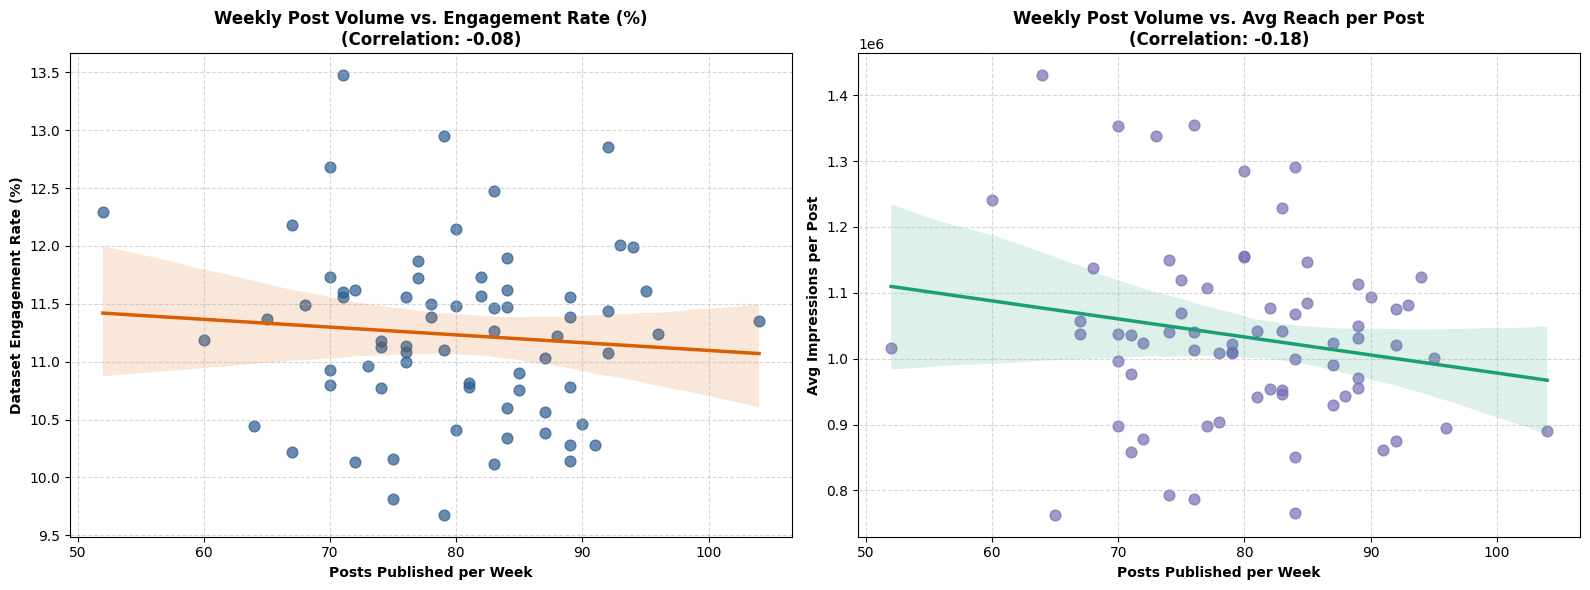

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Posts per Week vs. Engagement Rate (%) Scatter + Trendline
sns.regplot(
    data=weekly_summary,
    x='Posts_Per_Week',
    y='Dataset_Engagement_Rate_%',
    ax=axes[0],
    color='#2b5c8f',
    scatter_kws={'alpha': 0.7, 's': 60},
    line_kws={'color': '#d95f02', 'linewidth': 2.5},
)
axes[0].set_title(
    f'Weekly Post Volume vs. Engagement Rate (%)\n(Correlation: {corr_engagement_rate:.2f})',
    fontweight='bold',
)
axes[0].set_xlabel('Posts Published per Week', fontweight='bold')
axes[0].set_ylabel('Dataset Engagement Rate (%)', fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Posts per Week vs. Average Impressions per Post
sns.regplot(
    data=weekly_summary,
    x='Posts_Per_Week',
    y='Avg_Impressions_Per_Post',
    ax=axes[1],
    color='#7570b3',
    scatter_kws={'alpha': 0.7, 's': 60},
    line_kws={'color': '#1b9e77', 'linewidth': 2.5},
)
axes[1].set_title(
    f'Weekly Post Volume vs. Avg Reach per Post\n(Correlation: {corr_impressions:.2f})',
    fontweight='bold',
)
axes[1].set_xlabel('Posts Published per Week', fontweight='bold')
axes[1].set_ylabel('Avg Impressions per Post', fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
weekly_lag = weekly_summary.copy()

# Previous week's performance
weekly_lag['Previous_Week_Reach'] = (
    weekly_lag['Avg_Impressions_Per_Post'].shift(1)
)

weekly_lag['Previous_Week_Engagement'] = (
    weekly_lag['Dataset_Engagement_Rate_%'].shift(1)
)

weekly_lag = weekly_lag.dropna()

print(
    "Previous Week Reach vs Current Week Post Volume:",
    weekly_lag['Previous_Week_Reach'].corr(
        weekly_lag['Posts_Per_Week']
    )
)

print(
    "Previous Week Engagement vs Current Week Post Volume:",
    weekly_lag['Previous_Week_Engagement'].corr(
        weekly_lag['Posts_Per_Week']
    )
)

Previous Week Reach vs Current Week Post Volume: -0.06862259558682632
Previous Week Engagement vs Current Week Post Volume: -0.24244426808001576


Weeks following low-engagement periods tend to have higher posting volumes. Might be because , when one post doesn't get enough engagments. some people content farm so it has more reach

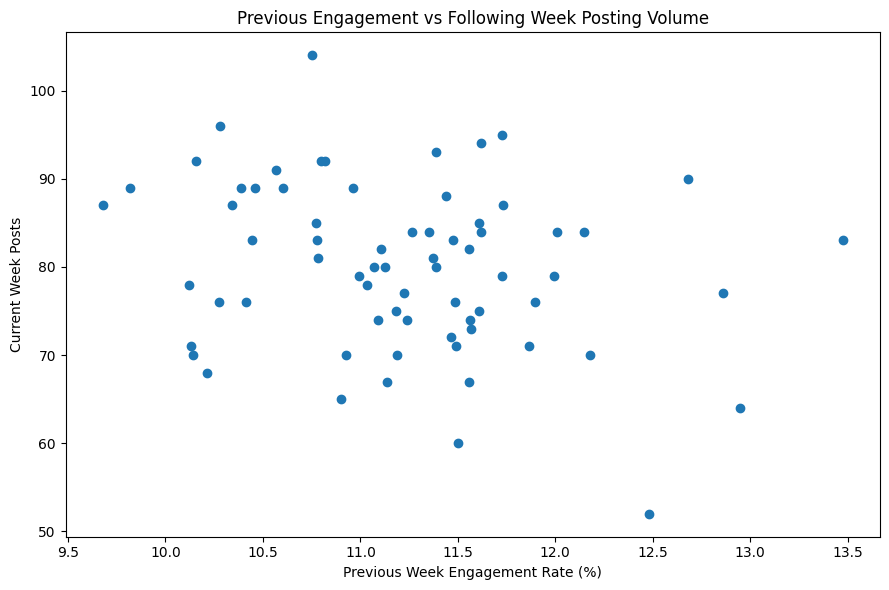

In [ ]:
plt.figure(figsize=(9, 6))

plt.scatter(
    weekly_lag['Previous_Week_Engagement'],
    weekly_lag['Posts_Per_Week']
)

plt.xlabel('Previous Week Engagement Rate (%)')
plt.ylabel('Current Week Posts')
plt.title('Previous Engagement vs Following Week Posting Volume')

plt.tight_layout()
plt.show()

In [ ]:
weekly_lag['Previous_Engagement_Group'] = pd.qcut(
    weekly_lag['Previous_Week_Engagement'],
    q=3,
    labels=['Low Engagement', 'Medium Engagement', 'High Engagement']
)

response = weekly_lag.groupby(
    'Previous_Engagement_Group',
    observed=True
)['Posts_Per_Week'].mean()

print(response)

Previous_Engagement_Group
Low Engagement      84.04
Medium Engagement   78.57
High Engagement     77.61
Name: Posts_Per_Week, dtype: float64


## Posts

In [ ]:
top_posts = df.sort_values(
    'Impressions',
    ascending=False
).head(10)

top_posts[[
    'Post_ID',
    'Platform',
    'Content_Type',
    'Content_Category',
    'Post_Type',
    'Region',
    'Impressions',
    'Views',
    'Likes',
    'Comments',
    'Shares',
    'Engagement',
    'Engagement_Rate',
    'Clicks',
    'Click_Through_Rate',
    'Main_Hashtag',
    'Post_Date'
]]

,Post_ID,Platform,Content_Type,Content_Category,Post_Type,Region,Impressions,Views,Likes,Comments,Shares,Engagement,Engagement_Rate,Clicks,Click_Through_Rate,Main_Hashtag,Post_Date
5533,Post_1513,Facebook,Sponsored,Product Promotion,Text,UK,5282874,4145852,609461,204540,185549,588798,0.14,74488.00,0.01,#FeatureHighlight,2024-01-31
1499,Post_1513,YouTube,Organic,Product Promotion,Video,UK,5282874,4145852,609461,204540,185549,536718,0.13,NaN,NaN,#ProductDemo,2024-01-31
1194,Post_1206,YouTube,Sponsored,Educational,Video,Australia,5204803,4188630,786826,211275,127438,761302,0.18,NaN,NaN,#CustomerStory,2024-09-08
580,Post_590,YouTube,Organic,Educational,Video,Japan,5180453,4238944,969932,159250,285780,821024,0.19,NaN,NaN,#CustomerStory,2025-04-13
4957,Post_590,LinkedIn,Organic,Educational,Article,Japan,5180453,4238944,969932,159250,285780,1032271,0.24,81333.00,0.02,#DidYouKnow,2025-04-13
3434,Post_3474,YouTube,Organic,Entertainment,Video,Australia,5117214,4118125,632935,188449,304982,363366,0.09,NaN,NaN,#TrendingNow,2024-08-19
1072,Post_1083,Instagram,Organic,Product Promotion,Video,Brazil,5070315,4076669,968263,155097,285533,352092,0.09,NaN,NaN,#ProductDemo,2025-03-23
151,Post_155,X.com,Organic,Product Promotion,Video,Canada,5028894,3930019,432543,111597,265268,382723,0.10,NaN,NaN,#ProductDemo,2024-08-25
1379,Post_1393,TikTok,Organic,Product Promotion,Video,India,4973577,4430104,981669,206228,295824,434276,0.10,88032.00,0.02,#ProductDemo,2024-08-01
2282,Post_2306,X.com,Organic,Product Promotion,Video,UK,4791345,3741956,811219,176348,158791,470418,0.13,NaN,NaN,#ProductDemo,2024-04-04


In [ ]:

# 1. Ensure required calculated metrics exist in your dataframe
# Engagement Rate (%) = (Engagement / Impressions) * 100
if 'Engagement_Rate' not in df.columns:
    df['Engagement_Rate'] = (df['Engagement'] / df['Impressions']) * 100

# CTR (%) = (Clicks / Impressions) * 100 (if Clicks column exists)
if 'CTR' not in df.columns and 'Clicks' in df.columns:
    df['CTR'] = (df['Clicks'] / df['Impressions']) * 100

# Identify available metadata columns to display for context
context_cols = [
    col
    for col in [
        'Post_ID',
        'Platform',
        'Post_Type',
        'Content_Type',
        'Region',
        'Primary_Hashtag',
    ]
    if col in df.columns
]

# 2. Map definitions of success to their underlying dataframe columns
success_definitions = {
    '🥇 Most Visible': 'Impressions',
    '👀 Most Watched': 'Views',
    '❤️ Most Engaging': 'Engagement',
    '📈 Most Efficient': 'Engagement_Rate',
    '🔄 Most Shareable': 'Shares',
    '💬 Most Discussion-Generating': 'Comments',
    '🎯 Best at Driving Traffic': 'CTR',
}

# 3. Extract the top post for each category
top_posts_list = []

for category, metric in success_definitions.items():
    if metric in df.columns:
        # Find index of the maximum value for the metric
        top_idx = df[metric].idxmax()
        top_row = df.loc[top_idx].copy()

        # Build entry dictionary
        entry = {
            'Success Category': category,
            'Metric Used': metric,
            'Peak Value': (
                f"{top_row[metric]:.2f}%"
                if 'Rate' in metric or metric == 'CTR'
                else f'{top_row[metric]:,.0f}'
            ),
        }

        # Append contextual metadata columns
        for col in context_cols:
            entry[col] = top_row[col]

        top_posts_list.append(entry)

# Convert to DataFrame
top_posts_df = pd.DataFrame(top_posts_list)

print('--- 🏆 Top Posts Across Different Definitions of Success ---')
print(top_posts_df.to_string(index=False))

--- 🏆 Top Posts Across Different Definitions of Success ---
            Success Category     Metric Used Peak Value   Post_ID Platform   Post_Type Content_Type    Region
              🥇 Most Visible     Impressions  5,282,874 Post_1513  YouTube       Video      Organic        UK
              👀 Most Watched           Views  4,430,104 Post_1393   TikTok       Video      Organic     India
            ❤️ Most Engaging      Engagement  1,032,271  Post_590 LinkedIn     Article      Organic     Japan
            📈 Most Efficient Engagement_Rate      0.27%    Post_5   TikTok       Video      Organic    Brazil
            🔄 Most Shareable          Shares    304,982 Post_3474  YouTube       Video      Organic Australia
💬 Most Discussion-Generating        Comments    232,658  Post_978  YouTube       Video    Sponsored    Brazil
   🎯 Best at Driving Traffic             CTR      3.00%  Post_842 LinkedIn Live Stream      Organic     India


In [ ]:

# 1. Define thresholds (Median is robust against extreme viral outliers)
reach_threshold = df['Impressions'].median()
engagement_threshold = df['Engagement_Rate'].median()


# 2. Assign Quadrants
def classify_post(row):
    high_reach = row['Impressions'] >= reach_threshold
    high_eng = row['Engagement_Rate'] >= engagement_threshold

    if high_reach and high_eng:
        return '💎 Star Posts'
    elif high_reach and not high_eng:
        return '📢 Awareness'
    elif not high_reach and high_eng:
        return '⭐ Hidden Gems'
    else:
        return '❌ Weak'


df['Post_Category'] = df.apply(classify_post, axis=1)

In [ ]:
df.columns

Index(['Post_ID', 'Platform', 'Content_Type', 'Content_Category', 'Post_Type',
       'Region', 'Longitude', 'Latitude', 'Engagement', 'Views', 'Likes',
       'Shares', 'Comments', 'Engagement_Rate', 'Impressions', 'Video_Views',
       'Live_Stream_Views', 'Clicks', 'Click_Through_Rate', 'Main_Hashtag',
       'Post_Published_At', 'Post_Date', 'Post_Hour', 'Engagement_Level',
       'Day', 'Month', 'Year', 'Social_Interactions', 'Spatial_Cluster',
       'Day_Name', 'Year_Month', 'Month_Name', 'Year_Week', 'CTR',
       'Post_Category'],
      dtype='str')

In [214]:
# Assuming your column is named 'Content_Type' or 'Post_Type'
content_column_name = 'Content_Type' if 'Content_Type' in df.columns else 'Post_Type'

sponsorship_breakdown = analyze_dimension(df, content_column_name)

print("--- 💎 Star Post Rate by Organic vs. Sponsored ---")
print(sponsorship_breakdown)

--- 💎 Star Post Rate by Organic vs. Sponsored ---
  Content_Type  total_posts  star_posts  star_conversion_rate
1    Sponsored          952         172                 18.07
0      Organic         4645         687                 14.79


In [215]:
# Identify the column containing 'Organic' or 'Sponsored'
content_column_name = 'Content_Type' if 'Content_Type' in df.columns else 'Post_Type'

# Create an explicit Is_Sponsored boolean column (True if sponsored, False if organic)
df['Is_Sponsored'] = df[content_column_name].astype(str).str.lower().str.contains('sponsored')

# Or as a readable text label:
df['Sponsorship_Status'] = np.where(df['Is_Sponsored'], 'Sponsored', 'Organic')

# Run the analysis
sponsorship_breakdown = analyze_dimension(df, 'Sponsorship_Status')

print("--- 💎 Star Post Breakdown: Organic vs. Sponsored ---")
print(sponsorship_breakdown)

--- 💎 Star Post Breakdown: Organic vs. Sponsored ---
  Sponsorship_Status  total_posts  star_posts  star_conversion_rate
1          Sponsored          952         172                 18.07
0            Organic         4645         687                 14.79


In [208]:
# Create a binary target indicator for easy group metrics
df['is_star'] = df['Post_Category'] == '💎 Star Posts'


def analyze_dimension(df, column):
    """Calculates total posts, Star Post counts, and Star Post % per category."""
    summary = (
        df.groupby(column)
        .agg(
            total_posts=('is_star', 'count'),
            star_posts=('is_star', 'sum'),
            star_conversion_rate=('is_star', 'mean'),
        )
        .reset_index()
    )

    summary['star_conversion_rate'] = (
        summary['star_conversion_rate'] * 100
    ).round(2)
    return summary.sort_values(by='star_conversion_rate', ascending=False)


# Example usage for your variables:
platform_breakdown = analyze_dimension(df, 'Platform')
content_type_breakdown = analyze_dimension(df, 'Post_Type')
country_breakdown = analyze_dimension(df, 'Region')
sponsorship_breakdown = analyze_dimension(df, 'Is_Sponsored')

In [216]:
# 1. Best Publish Time for Star Posts
df['Publish_Hour'] = pd.to_datetime(df['Post_Date']).dt.hour
timing_analysis = (
    df.groupby('Publish_Hour')['is_star']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
)

# 2. Hashtag Association Analysis
from collections import Counter

# Explode hashtags column assuming it contains lists or comma-separated strings
star_hashtags = df[df['is_star']]['Main_Hashtag'].dropna().str.split(',').explode()
top_star_hashtags = Counter([tag.strip() for tag in star_hashtags]).most_common(
    10
)

C:\Users\salma\AppData\Local\Temp\ipykernel_22148\2759589432.py:40: UserWarning: Glyph 128226 (\N{PUBLIC ADDRESS LOUDSPEAKER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\salma\AppData\Local\Temp\ipykernel_22148\2759589432.py:40: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\salma\AppData\Local\Temp\ipykernel_22148\2759589432.py:40: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\salma\AppData\Local\Temp\ipykernel_22148\2759589432.py:40: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\salma\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128226 (\N{PUBLIC ADDRESS LOUDSPEAKER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\salma\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.p

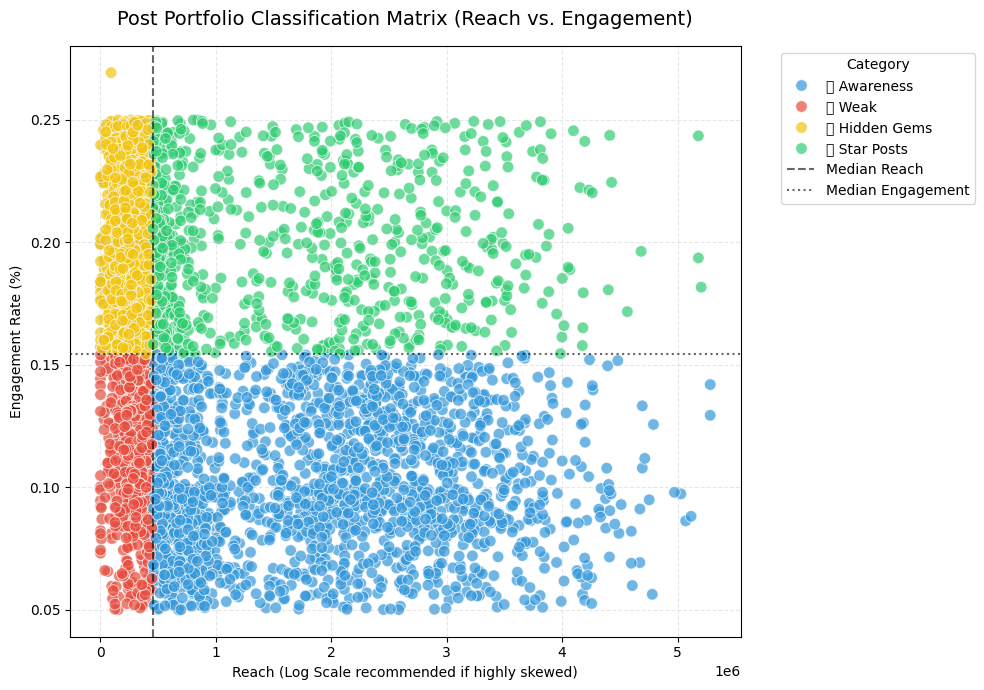

In [217]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='Impressions',
    y='Engagement_Rate',
    hue='Post_Category',
    palette={
        '💎 Star Posts': '#2ecc71',
        '📢 Awareness': '#3498db',
        '⭐ Hidden Gems': '#f1c40f',
        '❌ Weak': '#e74c3c',
    },
    alpha=0.7,
    s=70,
)

# Add median benchmark lines
plt.axvline(
    reach_threshold, color='black', linestyle='--', alpha=0.6, label='Median Reach'
)
plt.axhline(
    engagement_threshold,
    color='black',
    linestyle=':',
    alpha=0.6,
    label='Median Engagement',
)

plt.title(
    'Post Portfolio Classification Matrix (Reach vs. Engagement)',
    fontsize=14,
    pad=15,
)
plt.xlabel('Reach (Log Scale recommended if highly skewed)')
plt.ylabel('Engagement Rate (%)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [218]:
def format_number(x):
    if pd.isna(x):
        return 'N/A'
    elif abs(x) >= 1_000_000:
        return f'{x / 1_000_000:.2f}M'
    elif abs(x) >= 1_000:
        return f'{x / 1_000:.1f}K'
    else:
        return f'{x:.0f}'

In [219]:
# 1. Define Top 10% cutoff (90th percentile) or isolate "Star Posts"
# You can use the top 10% highest engagement rate posts as your 'Top Posts' group
top_threshold = df['Engagement'].quantile(0.90)

top_posts = df[df['Engagement'] >= top_threshold]
typical_posts =  df[df['Engagement'] < top_threshold] # Entire dataset serving as the baseline cohort

# 2. Key numeric metrics to benchmark
metrics = ['Impressions', 'Views', 'Engagement', 'Likes', 'Comments', 'Shares', 'Engagement_Rate'] # add 'CTR' if available
metrics_to_use = [m for m in metrics if m in df.columns]

# 3. Calculate Average (Mean) & Typical (Median) values
comparison_list = []

for m in metrics_to_use:
    typical_val = typical_posts[m].median()  # Median represents the true "typical" post
    top_val = top_posts[m].median()
    
    multiplier = top_val / typical_val if typical_val > 0 else np.nan
    pct_lift = ((top_val - typical_val) / typical_val) * 100 if typical_val > 0 else np.nan
    
    comparison_list.append({
        'Metric': m,
        'Typical Post (Median)': format_number(typical_val),
        'Top 10% Post (Median)': format_number(top_val),
        'Multiplier Lift': f"{multiplier:.1f}x",
        '% Increase': f"+{pct_lift:.1f}%"
                        })

comparison_df = pd.DataFrame(comparison_list)

print("--- 📊 Top-Performing Post vs. Typical Post Baseline ---")
print(comparison_df.to_string(index=False))

--- 📊 Top-Performing Post vs. Typical Post Baseline ---
         Metric Typical Post (Median) Top 10% Post (Median) Multiplier Lift % Increase
    Impressions                406.0K                 3.04M            7.5x    +647.9%
          Views                339.9K                 2.55M            7.5x    +651.7%
     Engagement                 53.7K                388.5K            7.2x    +623.2%
          Likes                 59.9K                423.1K            7.1x    +606.6%
       Comments                 13.5K                 98.6K            7.3x    +628.3%
         Shares                 18.7K                136.3K            7.3x    +630.5%
Engagement_Rate                     0                     0            1.1x     +12.4%


C:\Users\salma\AppData\Local\Temp\ipykernel_22148\1484651780.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


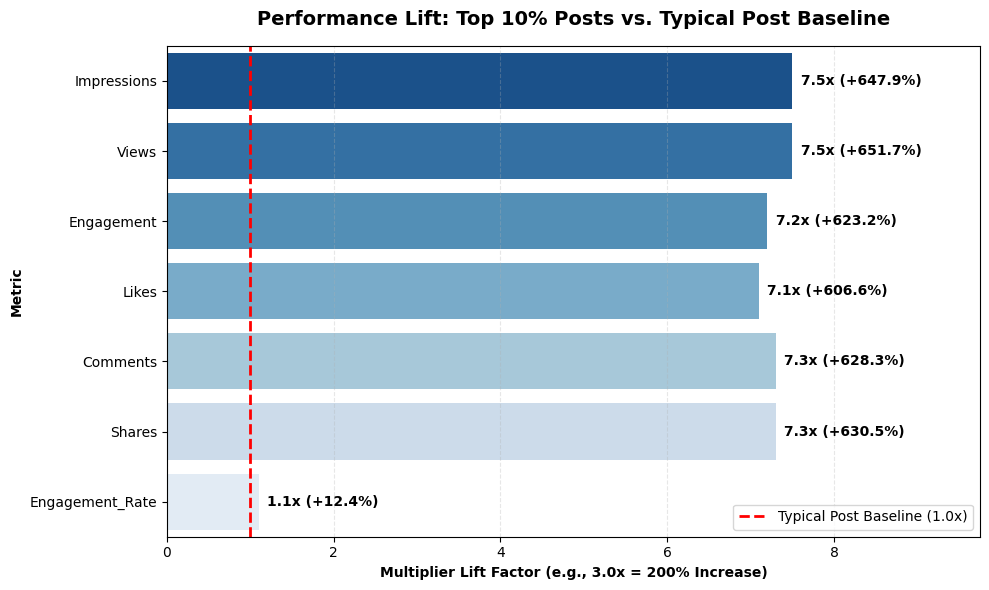

In [220]:


# Prepare data for plotting multipliers
plot_data = comparison_df.copy()
plot_data['Numeric_Multiplier'] = plot_data['Multiplier Lift'].str.replace('x', '').astype(float)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=plot_data,
    x='Numeric_Multiplier',
    y='Metric',
    palette='Blues_r'
)

# Draw baseline marker at 1.0x
plt.axvline(1.0, color='red', linestyle='--', linewidth=2, label='Typical Post Baseline (1.0x)')

# Annotate bars with multiplier text
for i, row in enumerate(plot_data.itertuples()):
    ax.text(
        row.Numeric_Multiplier + 0.1,
        i,
        f"{row.Numeric_Multiplier:.1f}x ({getattr(row, '_5')})",
        va='center',
        fontweight='bold'
    )

plt.title('Performance Lift: Top 10% Posts vs. Typical Post Baseline', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Multiplier Lift Factor (e.g., 3.0x = 200% Increase)', fontweight='bold')
plt.ylabel('Metric', fontweight='bold')
plt.xlim(0, plot_data['Numeric_Multiplier'].max() * 1.3)
plt.grid(True, linestyle='--', alpha=0.3, axis='x')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()